In [1]:
import tensorflow as tf
from tensorflow.keras import layers

# ----------------------------
# NOTE: PixelShuffleResize has been removed. Upsampling now uses
# layers.UpSampling2D (bilinear) followed by a learnable refine conv,
# with an exact crop/pad to hit the target spatial size.
# ----------------------------

# ----------------------------
# NOTE: GatedSpatialAttention has been removed. The refinement step
# that used it (self.refine(fused)) has been dropped from the forward
# pass below — merged features now flow straight from the canvas merge
# into the structure heads (or final projection).
# ----------------------------

# ----------------------------
# Updated DualBranch Layer:
# UpSampling2D-based upsampling + Learnable prior fusion (NO pixelwise maximum)
# ----------------------------
@tf.keras.utils.register_keras_serializable(package="Custom")
class DualBranchCanvasUpsample2D_SpatialGate(layers.Layer):
    """
    UpSampling2D upsampling everywhere (replaces PixelShuffleResize for features/skip and optionally priors)
    PLUS learnable prior fusion:

      GAP(pred) + GAP(prior) -> Dense -> Dense(1) -> project back (B,1,1,1) gate
      fused = gate*prior + (1-gate)*pred
      then DepthwiseConv(act) -> PointwiseConv to produce final map (B,H,W,1)

    Priors influence ONLY the structure maps (center/boundary), then those modulate features as before.
    """

    def __init__(
        self,
        scale=2,
        filters=64,
        method="bilinear",
        attention_kernel=3,
        use_structure_heads=True,
        n_centers=8,
        center_sharpness=9.0,
        boundary_suppress=0.4,
        learnable_temperature=True,
        learnable_prior_resize=True,
        # prior-fusion settings
        prior_fusion_hidden_ratio=4,  # hidden = filters//ratio
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.scale = int(scale)
        self.filters = int(filters)
        self.method = method
        self.attention_kernel = int(attention_kernel)
        self.use_structure_heads = bool(use_structure_heads)
        self.n_centers = int(n_centers)
        self.center_sharpness = float(center_sharpness)
        self.boundary_suppress = float(boundary_suppress)
        self.learnable_temperature = bool(learnable_temperature)

        self.learnable_prior_resize = bool(learnable_prior_resize)
        self.prior_fusion_hidden_ratio = int(prior_fusion_hidden_ratio)

        # ---------------- Projection & Attention ----------------
        self.proj_high = layers.Conv2D(filters, 1, padding="same", activation="selu", name="proj_high")
        self.proj_base = layers.Conv2D(filters, 1, padding="same", activation="linear", name="proj_base")
        self.skip_proj = layers.Conv2D(filters, 1, padding="same", use_bias=False, name="skip_proj")

        self.attention_head = tf.keras.Sequential(
            [
                layers.DepthwiseConv2D(attention_kernel, padding="same", activation="selu", use_bias=False),
                layers.Conv2D(filters, 1, padding="same", activation="selu"),
                layers.Conv2D(1, 1, padding="same", activation="sigmoid"),
            ],
            name="spatial_attention",
        )

        # ---------------- UpSampling2D-based upsamplers ----------------
        self.up_feat = layers.UpSampling2D(size=(self.scale, self.scale), interpolation=self.method, name="up_feat")
        self.up_feat_refine = tf.keras.Sequential(
            [
                layers.DepthwiseConv2D(3, padding="same", use_bias=False),
                layers.Conv2D(filters, 1, padding="same", activation="selu"),
            ],
            name="up_feat_refine",
        )

        if self.learnable_prior_resize:
            self.up_prior = layers.UpSampling2D(size=(self.scale, self.scale), interpolation=self.method, name="up_prior")
            self.up_prior_refine = tf.keras.Sequential(
                [
                    layers.DepthwiseConv2D(3, padding="same", use_bias=False),
                    layers.Conv2D(1, 1, padding="same", activation="selu"),
                ],
                name="up_prior_refine",
            )
        else:
            self.up_prior = None
            self.up_prior_refine = None

        # ---------------- Canvas ----------------
        self.canvas_weight = None
        self.alpha_weight = self.add_weight(
            shape=(1,), initializer=tf.keras.initializers.Constant(1.0), trainable=True, name="alpha_weight"
        )
        self.beta_weight = self.add_weight(
            shape=(1,), initializer=tf.keras.initializers.Constant(0.5), trainable=True, name="beta_weight"
        )

        # ---------------- Final projection (refinement step removed) ----------------
        self.final = layers.Conv2D(filters, 1, padding="same", activation="selu", name="final_head")

        # ---------------- Structural Heads ----------------
        self.assign_logits = layers.Conv2D(self.n_centers, 1, padding="same", use_bias=True)
        self.center_proj = layers.Conv2D(filters, 1, padding="same", activation=None)

        self.boundary_depthwise = layers.DepthwiseConv2D(3, padding="same", use_bias=False, name="laplace_dw")
        self.boundary_refine = tf.keras.Sequential(
            [
                layers.Conv2D(filters // 2, 3, padding="same", activation="selu"),
                layers.Conv2D(1, 1, padding="same", activation="sigmoid"),
            ],
            name="boundary_refine",
        )
        self.boundary_gate_net = tf.keras.Sequential(
            [
                layers.Conv2D(filters // 2, 3, padding="same", activation="selu"),
                layers.Conv2D(1, 1, padding="same", activation="sigmoid"),
            ],
            name="boundary_gate_net",
        )

        self.boundary_gate_scalar = None
        self.center_temp = None
        self.center_sigma = None

        # ---------------- Learnable prior fusion blocks (CENTER) ----------------
        hid = max(4, filters // self.prior_fusion_hidden_ratio)

        self.center_gap = layers.GlobalAveragePooling2D(name="center_prior_gap")
        self.center_fc1 = layers.Dense(hid, activation="selu", name="center_prior_fc1")
        self.center_gate = layers.Dense(1, activation="sigmoid", name="center_prior_gate")  # scalar gate

        self.center_dw = layers.DepthwiseConv2D(3, padding="same", activation="selu", name="center_prior_dw")
        self.center_pw = layers.Conv2D(1, 1, padding="same", activation="sigmoid", name="center_prior_pw")

        # ---------------- Learnable prior fusion blocks (BOUNDARY) ----------------
        self.boundary_gap = layers.GlobalAveragePooling2D(name="boundary_prior_gap")
        self.boundary_fc1 = layers.Dense(hid, activation="selu", name="boundary_prior_fc1")
        self.boundary_gate = layers.Dense(1, activation="sigmoid", name="boundary_prior_gate")  # scalar gate

        self.boundary_dw2 = layers.DepthwiseConv2D(3, padding="same", activation="selu", name="boundary_prior_dw")
        self.boundary_pw2 = layers.Conv2D(1, 1, padding="same", activation="sigmoid", name="boundary_prior_pw")

    # ---------------- Canvas Initialization ----------------
    def _init_canvas(self, shape, dtype):
        init = tf.keras.initializers.HeNormal(seed=54)
        w = init(shape=shape, dtype=dtype)
        return tf.clip_by_value(w, 0.0, 1.0)

    # ---------------- Build ----------------
    def build(self, input_shape):
        if not isinstance(input_shape, (list, tuple)) or len(input_shape) not in [2, 4]:
            raise ValueError(
                "DualBranchCanvasUpsample2D_SpatialGate expects [low_res, skip_res] or "
                "[low_res, skip_res, prior_centers, prior_boundaries] inputs."
            )

        canvas_init = self._init_canvas((1, 1, 1, self.filters), tf.float32)
        self.canvas_weight = tf.Variable(
            initial_value=canvas_init, trainable=True, name="canvas_weight", dtype=tf.float32
        )

        self.boundary_gate_scalar = self.add_weight(
            shape=(1,),
            initializer=tf.keras.initializers.Constant(1.0 - self.boundary_suppress),
            trainable=True,
            name="boundary_gate_scalar",
        )

        if self.learnable_temperature:
            self.center_temp = self.add_weight(
                shape=(1,),
                initializer=tf.keras.initializers.Constant(self.center_sharpness),
                trainable=True,
                name="center_temperature",
            )
        else:
            self.center_temp = tf.constant(self.center_sharpness, dtype=tf.float32)

        self.center_sigma = self.add_weight(
            shape=(self.n_centers,),
            initializer=tf.keras.initializers.Constant(1.0),
            trainable=True,
            name="center_sigma",
        )

        super().build(input_shape)

    # ---------------- Learnable upsample-to-target helper ----------------
    def _upsample_to(self, x, up_layer, refine, target_h, target_w):
        x = up_layer(x)
        if refine is not None:
            x = refine(x)
        # exact match by crop/pad (non-interpolating) for odd input sizes
        x = tf.image.resize_with_crop_or_pad(x, target_h, target_w)
        return x

    # ---------------- Learnable fusion (replaces pixelwise maximum) ----------------
    def _learnable_fuse_prior(self, pred_map, prior_map, gap, fc1, gate_fc, dw, pw):
        """
        pred_map/prior_map: (B,H,W,1)
        gate: scalar per-sample from GAP(pred)+GAP(prior)
        fused map refined by DWConv(act)+PWConv(sigmoid)
        """
        g_pred = gap(pred_map)   # (B,1) effectively after GAP; in TF it's (B,)
        g_prior = gap(prior_map)

        g = tf.concat([g_pred, g_prior], axis=-1)  # (B,2)
        h = fc1(g)
        gate = gate_fc(h)                          # (B,1)
        gate = tf.reshape(gate, [-1, 1, 1, 1])     # project back (broadcast)

        fused = gate * prior_map + (1.0 - gate) * pred_map
        fused = dw(fused)
        fused = pw(fused)
        return fused

    # ---------------- GMM-based Center & Boundary ----------------
    def _compute_soft_centers_gmm(self, feat, prior_centers=None, prior_boundaries=None):
        center_map, boundary_map = self._compute_centers_boundaries(feat)
        target_h, target_w = tf.shape(center_map)[1], tf.shape(center_map)[2]

        # --- learnable prior alignment + learnable fusion (NO tf.maximum) ---
        if prior_centers is not None:
            if self.up_prior is not None:
                prior_centers_up = self._upsample_to(
                    prior_centers, self.up_prior, self.up_prior_refine, target_h, target_w
                )
            else:
                prior_centers_up = tf.image.resize(prior_centers, (target_h, target_w), method="bilinear")
            prior_centers_up = tf.clip_by_value(prior_centers_up, 0.0, 1.0)

            center_map = self._learnable_fuse_prior(
                center_map, prior_centers_up,
                self.center_gap, self.center_fc1, self.center_gate,
                self.center_dw, self.center_pw
            )

        if prior_boundaries is not None:
            if self.up_prior is not None:
                prior_boundaries_up = self._upsample_to(
                    prior_boundaries, self.up_prior, self.up_prior_refine, target_h, target_w
                )
            else:
                prior_boundaries_up = tf.image.resize(prior_boundaries, (target_h, target_w), method="bilinear")
            prior_boundaries_up = tf.clip_by_value(prior_boundaries_up, 0.0, 1.0)

            boundary_map = self._learnable_fuse_prior(
                boundary_map, prior_boundaries_up,
                self.boundary_gap, self.boundary_fc1, self.boundary_gate,
                self.boundary_dw2, self.boundary_pw2
            )

        return center_map, boundary_map

    def _compute_centers_boundaries(self, feat):
        eps = 1e-9
        B = tf.shape(feat)[0]

        proj_feat = self.center_proj(feat)
        H, W, C = tf.shape(proj_feat)[1], tf.shape(proj_feat)[2], tf.shape(proj_feat)[3]
        feat_flat = tf.reshape(proj_feat, [B, H * W, C])

        logits = self.assign_logits(proj_feat)
        logits_flat = tf.reshape(logits, [B, H * W, self.n_centers])
        A_flat = tf.nn.softmax(logits_flat, axis=-1)

        A_flat_t = tf.transpose(A_flat, [0, 2, 1])
        denom = tf.reduce_sum(A_flat_t, axis=-1, keepdims=True) + eps
        prototypes = tf.matmul(A_flat_t, feat_flat) / denom

        sigma = tf.reshape(tf.maximum(self.center_sigma, 1e-6), [1, 1, self.n_centers, 1])

        feat_exp = tf.expand_dims(feat_flat, 2)
        proto_exp = tf.expand_dims(prototypes, 1)
        diff_sq = tf.reduce_sum((feat_exp - proto_exp) ** 2, axis=-1)
        gauss = tf.exp(-diff_sq / (2.0 * (sigma[..., 0] ** 2) + eps))
        resp = gauss / (tf.reduce_sum(gauss, axis=-1, keepdims=True) + eps)

        feat_norm = tf.nn.l2_normalize(feat_flat, axis=-1)
        proto_norm = tf.nn.l2_normalize(prototypes, axis=-1)
        sim = tf.matmul(feat_norm, proto_norm, transpose_b=True)

        weighted_sim = resp * sim
        per_pixel_strength = tf.reduce_max(weighted_sim, axis=-1, keepdims=True)

        sharpness = tf.maximum(self.center_temp, 1e-3)
        sharp = tf.pow(tf.nn.relu(per_pixel_strength) + eps, sharpness)
        max_img = tf.reduce_max(sharp, axis=[1, 2], keepdims=True) + eps
        center_map = sharp / max_img
        center_map = tf.reshape(center_map, [B, H, W, 1])

        resp_map = tf.reshape(tf.reduce_max(resp, axis=-1, keepdims=True), [B, H, W, 1])
        lap = self.boundary_depthwise(feat)
        lap_abs = tf.reduce_mean(tf.abs(lap), axis=-1, keepdims=True)
        refined_boundary = self.boundary_refine(lap_abs)
        spatial_gate = self.boundary_gate_net(feat)
        global_gate = tf.sigmoid(self.boundary_gate_scalar)
        boundary_map = refined_boundary * spatial_gate * global_gate * resp_map
        boundary_map = tf.clip_by_value(boundary_map, 0.0, 1.0)

        return tf.clip_by_value(center_map, 0.0, 1.0), boundary_map

    # ---------------- Forward ----------------
    def call(self, inputs, training=None):
        if len(inputs) == 2:
            low_res, skip_res = inputs
            prior_centers, prior_boundaries = None, None
        elif len(inputs) == 4:
            low_res, skip_res, prior_centers, prior_boundaries = inputs
        else:
            raise ValueError("Expected 2 or 4 inputs: [low_res, skip_res] optionally with priors.")

        high_proj = self.proj_high(low_res)
        base_proj = self.proj_base(low_res)
        alpha = self.attention_head(tf.concat([low_res, high_proj, base_proj], axis=-1))
        fused_low = alpha * high_proj + (1.0 - alpha) * base_proj

        target_h = tf.shape(low_res)[1] * self.scale
        target_w = tf.shape(low_res)[2] * self.scale

        # UpSampling2D-based upsampling (features + skip)
        upsampled = self._upsample_to(fused_low, self.up_feat, self.up_feat_refine, target_h, target_w)
        skip_proj = self.skip_proj(skip_res)
        skip_up = self._upsample_to(skip_proj, self.up_feat, self.up_feat_refine, target_h, target_w)

        fused = (upsampled + skip_up) * self.canvas_weight
        refined = fused

        if self.use_structure_heads:
            center_map, boundary_map = self._compute_soft_centers_gmm(refined, prior_centers, prior_boundaries)
            refined = refined * (self.alpha_weight + center_map) - boundary_map * self.beta_weight
            out = self.final(refined)
            return out, center_map, boundary_map

        out = self.final(refined)
        return out

    # ---------------- Config ----------------
    def get_config(self):
        cfg = super().get_config()
        cfg.update(
            {
                "scale": self.scale,
                "filters": self.filters,
                "method": self.method,
                "attention_kernel": self.attention_kernel,
                "use_structure_heads": self.use_structure_heads,
                "n_centers": self.n_centers,
                "center_sharpness": self.center_sharpness,
                "boundary_suppress": self.boundary_suppress,
                "learnable_temperature": self.learnable_temperature,
                "learnable_prior_resize": self.learnable_prior_resize,
                "prior_fusion_hidden_ratio": self.prior_fusion_hidden_ratio,
            }
        )
        return cfg

2026-09-23 11:28:49.818786: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-23 11:28:49.856733: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-23 11:28:49.856801: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-23 11:28:49.859186: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-23 11:28:49.868458: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf
from tensorflow.keras import layers

@tf.keras.utils.register_keras_serializable(package="Custom")
class RadialWaveEvolutionaryConv(layers.Layer):

    def __init__(self,
                 num_patches=4,
                 num_feature_maps=32,
                 kernel_size=3,
                 **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.num_feature_maps = num_feature_maps
        self.kernel_size = kernel_size

    def build(self, input_shape):

        _, H, W, C = input_shape

        self.H = H
        self.W = W

        self.patch_h = H // self.num_patches
        self.patch_w = W // self.num_patches

        # Decision projection
        self.decision_filters = self.add_weight(
            shape=(C, self.num_feature_maps),
            initializer=tf.keras.initializers.GlorotNormal(),
            trainable=True,
            name="decision_space_filters"
        )

        # Convolution kernel
        self.gaussian_kernel = self.add_weight(
            shape=(self.kernel_size,
                   self.kernel_size,
                   C,
                   self.num_feature_maps),
            initializer=tf.keras.initializers.HeNormal(),
            trainable=True,
            name="gaussian_mutation_kernel"
        )

        # Learnable sigma (no user input)
        self.sigma = self.add_weight(
            shape=(),
            initializer=tf.keras.initializers.Constant(0.1),
            trainable=True,
            name="wave_sigma"
        )

        super().build(input_shape)

    # --------------------------------------------------
    # Pareto (tanh, batch-safe)
    # --------------------------------------------------
    def soft_pareto_score(self, objectives):
        # [B, N, M]

        f_i = tf.expand_dims(objectives, axis=2)  # [B, N, 1, M]
        f_j = tf.expand_dims(objectives, axis=1)  # [B, 1, N, M]

        domination = 0.5 * (1.0 + tf.nn.tanh(f_j - f_i))

        domination = tf.clip_by_value(domination, 1e-6, 1.0)

        domination_prod = tf.reduce_prod(domination, axis=-1)  # [B, N, N]

        score = tf.reduce_sum(domination_prod, axis=-1)  # [B, N]

        return score

    # --------------------------------------------------
    # Call
    # --------------------------------------------------
    def call(self, inputs):

        B = tf.shape(inputs)[0]
        C = tf.shape(inputs)[-1]

        # Patch extraction
        patches = tf.image.extract_patches(
            images=inputs,
            sizes=[1, self.patch_h, self.patch_w, 1],
            strides=[1, self.patch_h, self.patch_w, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        num_total_patches = self.num_patches * self.num_patches
        patch_area = self.patch_h * self.patch_w

        patches = tf.reshape(
            patches,
            [B, num_total_patches, patch_area, C]
        )

        patches_mean = tf.reduce_mean(patches, axis=2)  # [B, N, C]

        # Objectives
        objectives = tf.matmul(patches_mean, self.decision_filters)  # [B, N, M]

        # Pareto
        pareto_score = self.soft_pareto_score(objectives)

        weights = tf.nn.softmax(-pareto_score, axis=-1)
        weights = tf.expand_dims(weights, -1)

        weighted_objectives = objectives * weights

        # Radial wave
        center = tf.reduce_mean(weighted_objectives, axis=1, keepdims=True)

        radial_distance = tf.norm(weighted_objectives - center, axis=-1)

        sigma = tf.nn.softplus(self.sigma) + 1e-6

        wave = tf.math.special.bessel_j0(radial_distance)
        decay = tf.exp(- (radial_distance ** 2) / (2.0 * sigma ** 2))

        wave = wave * decay  # [B, N]

        # Expand to spatial
        wave = tf.reshape(wave, [B, self.num_patches, self.num_patches, 1])

        wave = tf.image.resize(
            wave,
            size=(self.H, self.W),
            method="nearest"
        )

        # Convolution
        conv_out = tf.nn.conv2d(
            inputs,
            self.gaussian_kernel,
            strides=1,
            padding="SAME"
        )

        return conv_out * wave

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "num_feature_maps": self.num_feature_maps,
            "kernel_size": self.kernel_size
        })
        return config

In [3]:
def conv_block(x,
               filters,
               kernel_size=3,
               activation="tanh",
               padding="same",
               decoder=False,
               num_patches=4,
               overlap_ratio=0.02,
               use_overlap=False,
               dilation_rate=2):

    res = x

    # ============================================================
    # ENCODER BLOCK
    # ============================================================
    if not decoder:


        # -------------------------------
        # Branch 2: Evolutionary Conv
        # -------------------------------
        x1 = RadialWaveEvolutionaryConv(
            num_patches=num_patches,
            num_feature_maps=filters,
            kernel_size=kernel_size
        )(x)

        x1 = layers.BatchNormalization()(x1)
        x1 = layers.Activation(activation)(x1)

        # -------------------------------
        # Depthwise Patch Attention
        # -------------------------------

        # Residual projection
        res = layers.Conv2D(filters, 1, padding=padding)(res)

        # Final fusion
        out = layers.Add()([res, x1])

        return out

    # ============================================================
    # DECODER BLOCK
    # ============================================================
    else:

        x1 = RadialWaveEvolutionaryConv(
            num_patches=num_patches,
            num_feature_maps=filters,
            kernel_size=kernel_size
        )(x)

        x1 = layers.BatchNormalization()(x1)
        x1 = layers.Activation(activation)(x1)

        return x1

In [4]:
import tensorflow as tf
from tensorflow.keras import layers

# ---------------------------------------------------------
# Geodesic Kernel Downsampler
# ---------------------------------------------------------

@tf.keras.utils.register_keras_serializable(package="Custom")
class GeodesicDownsample2D(layers.Layer):
    """
    Riemannian geodesic pooling via iterative intrinsic mean computation
    with a learnable diagonal metric and configurable robust weighting
    kernels (Huber, Tukey, Cauchy, Geman-McClure).
    """

    def __init__(
        self,
        pool_size=2,
        geo_iters=3,
        geo_temp=1.0,
        robust_kernel="huber",
        tukey_c=4.685,
        huber_delta=1.0,
        cauchy_alpha=1.0,
        geman_lambda=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.pool_size = pool_size
        self.geo_iters = geo_iters
        self.geo_temp = geo_temp
        self.robust_kernel = robust_kernel.lower()

        # kernel params
        self.huber_delta = huber_delta
        self.tukey_c = tukey_c
        self.cauchy_alpha = cauchy_alpha
        self.geman_lambda = geman_lambda

    def build(self, input_shape):
        c = input_shape[-1]
        self.metric_raw = self.add_weight(
            shape=(c,),
            initializer=tf.keras.initializers.Constant(1.0),
            trainable=True,
            name="metric_diag_unconstrained"
        )
        super().build(input_shape)

    # ---------------- robust weighting functions ----------------
    def _robust_weights(self, dist_sq):
        eps = 1e-9

        if self.robust_kernel == "huber":
            delta = self.huber_delta
            mask = dist_sq <= delta**2
            w_quad = 1.0
            w_lin = delta / (tf.sqrt(dist_sq) + eps)
            return tf.where(mask, w_quad, w_lin)

        if self.robust_kernel == "tukey":
            c = self.tukey_c
            mask = dist_sq <= c**2
            z = dist_sq / (c**2 + eps)
            w = (1 - z)**2
            return tf.where(mask, w, tf.zeros_like(dist_sq))

        if self.robust_kernel == "cauchy":
            a = self.cauchy_alpha
            return 1.0 / (1.0 + dist_sq / (a**2) + eps)

        if self.robust_kernel == "geman":
            lam = self.geman_lambda
            return 1.0 / ((1.0 + dist_sq / (lam + eps))**2)

        return tf.nn.softmax(-dist_sq, axis=-1)

    # ---------------- main pooling routine ----------------
    def call(self, x):
        if isinstance(self.pool_size, int):
            ph = pw = self.pool_size
        else:
            ph, pw = self.pool_size

        b, h, w, c = tf.unstack(tf.shape(x))
        pad_h = tf.math.floormod(-h, ph)
        pad_w = tf.math.floormod(-w, pw)
        x_pad = tf.pad(x, [[0,0],[0,pad_h],[0,pad_w],[0,0]])

        Hp = tf.shape(x_pad)[1] // ph
        Wp = tf.shape(x_pad)[2] // pw

        ksizes = [1, ph, pw, 1]
        strides = [1, ph, pw, 1]
        patches = tf.image.extract_patches(
            images=x_pad,
            sizes=ksizes,
            strides=strides,
            rates=[1,1,1,1],
            padding="VALID"
        )

        P = ph * pw
        patches = tf.reshape(patches, [b, Hp, Wp, P, c])

        metric = tf.nn.softplus(self.metric_raw) + 1e-6
        mean = tf.reduce_mean(patches, axis=3)

        for _ in range(self.geo_iters):
            diff = patches - tf.expand_dims(mean, axis=3)
            dist_sq = tf.reduce_sum(diff * diff * tf.reshape(metric, [1,1,1,1,c]), axis=-1)
            w = self._robust_weights(dist_sq)
            w = tf.nn.softmax(w / self.geo_temp, axis=-1)
            w = tf.expand_dims(w, axis=-1)
            mean = tf.reduce_sum(patches * w, axis=3)

        return mean

    def get_config(self):
        base = super().get_config()
        base.update({
            "pool_size": self.pool_size,
            "geo_iters": self.geo_iters,
            "geo_temp": self.geo_temp,
            "robust_kernel": self.robust_kernel,
            "tukey_c": self.tukey_c,
            "huber_delta": self.huber_delta,
            "cauchy_alpha": self.cauchy_alpha,
            "geman_lambda": self.geman_lambda
        })
        return base


# ---------------------------------------------------------
# NOTE: GatedSpatialAttention has been removed.
# The refinement step that used it (self.refine(...)) has
# been dropped from the forward pass below — fused features
# now flow directly from the skip/canvas merge into the
# structure heads (or final projection).
# ---------------------------------------------------------


# ---------------------------------------------------------
# Updated DualBranchCanvasDownsample2D_SpatialGate
#
# Changes from the original:
#   1. No more GatedSpatialAttention refinement step.
#   2. No more separate `refine_feat` input tensor. The skip
#      branch is now an average-pooled version of `in_feat`
#      itself, computed inside the layer with tf.nn.avg_pool2d
#      using the same pool_size as the geodesic downsampler.
#   3. call() now takes a single tensor `in_feat` instead of
#      a (in_feat, refine_feat) tuple, and build() expects a
#      single input_shape instead of a tuple of shapes.
# ---------------------------------------------------------
@tf.keras.utils.register_keras_serializable(package="Custom")
class DualBranchCanvasDownsample2D_SpatialGate(layers.Layer):

    def __init__(self,
                 pool_size=2,
                 filters=64,
                 attention_kernel=3,
                 use_structure_heads=True,
                 n_centers=8,
                 center_sharpness=9.0,
                 boundary_suppress=0.4,
                 learnable_temperature=True,
                 **kwargs):

        super().__init__(**kwargs)

        self.pool_size = pool_size
        self.filters = filters
        self.attention_kernel = attention_kernel
        self.use_structure_heads = use_structure_heads
        self.n_centers = n_centers
        self.center_sharpness = center_sharpness
        self.boundary_suppress = boundary_suppress
        self.learnable_temperature = learnable_temperature

        # Replace pooling with geodesic kernel
        self.geo_pool = GeodesicDownsample2D(pool_size=pool_size)

        # Projections
        self.proj_high = layers.Conv2D(filters, 1, padding='same', activation='selu')
        self.proj_base = layers.Conv2D(filters, 1, padding='same')
        self.skip_proj = layers.Conv2D(filters, 1, padding='same')

        # Spatial attention
        self.attention_head = tf.keras.Sequential([
            layers.DepthwiseConv2D(attention_kernel, padding='same', activation='selu'),
            layers.Conv2D(filters, 1, padding='same', activation='selu'),
            layers.Conv2D(1, 1, padding='same', activation='sigmoid')
        ])

        # Canvas
        self.canvas_weight = None
        self.alpha_weight = self.add_weight(shape=(1,), initializer='ones', trainable=True)
        self.beta_weight = self.add_weight(shape=(1,), initializer=tf.keras.initializers.Constant(0.5), trainable=True)

        # Final projection (refinement step removed)
        self.final = layers.Conv2D(filters, 3, padding='same', activation='selu')

        # Structure heads
        self.assign_logits = layers.Conv2D(self.n_centers, 1, padding='same')
        self.center_proj = layers.Conv2D(filters, 1, padding='same')

        self.boundary_depthwise = layers.DepthwiseConv2D(3, padding='same')
        self.boundary_refine = tf.keras.Sequential([
            layers.Conv2D(filters // 2, 3, padding='same', activation='selu'),
            layers.Conv2D(1, 1, padding='same', activation='sigmoid')
        ])
        self.boundary_gate_net = tf.keras.Sequential([
            layers.Conv2D(filters // 2, 3, padding='same', activation='selu'),
            layers.Conv2D(1, 1, padding='same', activation='sigmoid')
        ])

    def build(self, input_shape):
        # input_shape is now a single tensor shape (in_feat only)
        _, _, _, C = input_shape

        canvas_init = tf.keras.initializers.HeNormal(seed=54)(shape=(1, 1, 1, self.filters))
        self.canvas_weight = tf.Variable(canvas_init, trainable=True, name='canvas_weight')

        self.boundary_gate_scalar = self.add_weight(
            shape=(1,),
            initializer=tf.keras.initializers.Constant(1.0 - self.boundary_suppress),
            trainable=True
        )

        if self.learnable_temperature:
            self.center_temp = self.add_weight(
                shape=(1,),
                initializer=tf.keras.initializers.Constant(self.center_sharpness),
                trainable=True
            )
        else:
            self.center_temp = tf.constant(self.center_sharpness)

        self.center_sigma = self.add_weight(
            shape=(self.n_centers,),
            initializer='ones',
            trainable=True
        )

        super().build(input_shape)

    # ------------------------------------------------------
    # GMM structural mask logic (unchanged)
    # ------------------------------------------------------
    def _compute_soft_centers_gmm(self, feat):
        eps = 1e-9
        B = tf.shape(feat)[0]
        proj = self.center_proj(feat)
        H = tf.shape(proj)[1]
        W = tf.shape(proj)[2]
        C = tf.shape(proj)[3]

        flat = tf.reshape(proj, [B, H * W, C])
        logits = self.assign_logits(proj)
        logits_flat = tf.reshape(logits, [B, H * W, self.n_centers])
        A = tf.nn.softmax(logits_flat, axis=-1)
        A_t = tf.transpose(A, [0, 2, 1])
        denom = tf.reduce_sum(A_t, axis=-1, keepdims=True) + eps
        proto = tf.matmul(A_t, flat) / denom

        sigma = tf.reshape(tf.maximum(self.center_sigma, 1e-6), [1, 1, self.n_centers, 1])
        feat_exp = tf.expand_dims(flat, 2)
        proto_exp = tf.expand_dims(proto, 1)
        diff_sq = tf.reduce_sum((feat_exp - proto_exp) ** 2, axis=-1)
        gauss = tf.exp(-diff_sq / (2.0 * (sigma[..., 0] ** 2) + eps))
        resp = gauss / (tf.reduce_sum(gauss, axis=-1, keepdims=True) + eps)

        feat_n = tf.nn.l2_normalize(flat, axis=-1)
        proto_n = tf.nn.l2_normalize(proto, axis=-1)
        sim = tf.matmul(feat_n, proto_n, transpose_b=True)

        weighted_sim = resp * sim
        strength = tf.reduce_max(weighted_sim, axis=-1, keepdims=True)
        sharpness = tf.maximum(self.center_temp, 1e-3)
        sharp = tf.pow(tf.nn.relu(strength) + eps, sharpness)
        max_img = tf.reduce_max(sharp, axis=[1, 2], keepdims=True) + eps
        center_map = sharp / max_img
        center_map = tf.reshape(center_map, [B, H, W, 1])

        resp_map = tf.reshape(tf.reduce_max(resp, axis=-1, keepdims=True), [B, H, W, 1])
        lap = self.boundary_depthwise(feat)
        lap_abs = tf.reduce_mean(tf.abs(lap), axis=-1, keepdims=True)
        refined_boundary = self.boundary_refine(lap_abs)
        spatial_gate = self.boundary_gate_net(feat)

        boundary_map = refined_boundary * spatial_gate * tf.sigmoid(self.boundary_gate_scalar) * resp_map
        boundary_map = tf.clip_by_value(boundary_map, 0.0, 1.0)

        return tf.clip_by_value(center_map, 0.0, 1.0), boundary_map

    # ------------------------------------------------------
    # Forward path with geodesic pooling
    #
    # `in_feat` is now the ONLY input. The skip branch is
    # derived internally via average pooling of `in_feat`
    # (replacing the old separate `refine_feat` argument),
    # and the GatedSpatialAttention refinement step has been
    # removed entirely — the merged features flow straight
    # into the structure heads / final projection.
    # ------------------------------------------------------
    def call(self, in_feat):
        if isinstance(self.pool_size, int):
            ph = pw = self.pool_size
        else:
            ph, pw = self.pool_size

        pooled = self.geo_pool(in_feat)

        # Average-pooled skip branch, derived directly from in_feat
        pooled_ref = tf.nn.avg_pool2d(
            in_feat,
            ksize=[1, ph, pw, 1],
            strides=[1, ph, pw, 1],
            padding='SAME'
        )

        if tf.shape(pooled_ref)[1] != tf.shape(pooled)[1] or tf.shape(pooled_ref)[2] != tf.shape(pooled)[2]:
            pooled_ref = tf.image.resize(pooled_ref, tf.shape(pooled)[1:3], method='bilinear')

        high = self.proj_high(pooled)
        base = self.proj_base(pooled)
        alpha = self.attention_head(tf.concat([pooled, high, base], axis=-1))
        fused = alpha * high + (1 - alpha) * base

        skip = self.skip_proj(pooled_ref)
        fused = (fused + skip) * self.canvas_weight

        if self.use_structure_heads:
            center_map, boundary_map = self._compute_soft_centers_gmm(fused)
            fused = fused * (self.alpha_weight + center_map) - boundary_map * self.beta_weight
            return self.final(fused), center_map, boundary_map

        return self.final(fused)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'pool_size': self.pool_size,
            'filters': self.filters,
            'attention_kernel': self.attention_kernel,
            'use_structure_heads': self.use_structure_heads,
            'n_centers': self.n_centers,
            'center_sharpness': self.center_sharpness,
            'boundary_suppress': self.boundary_suppress,
            'learnable_temperature': self.learnable_temperature
        })
        return cfg

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

def split_branch_block(x, filters, dilation_rate=2, l2=1e-4, l1=1e-5):
    c = x.shape[-1]
    assert c % 4 == 0

    reg_k = regularizers.L2(l2)
    reg_b = regularizers.L1(l1)

    # -------------------------------------------------
    # Channel Split + gate
    # -------------------------------------------------
    splits = tf.split(x, num_or_size_splits=4, axis=-1)

    gate_logits = layers.GlobalAveragePooling2D()(x)
    gate_logits = layers.Dense(
        4,
        use_bias=True,
        kernel_regularizer=reg_k,
        bias_regularizer=reg_b
    )(gate_logits)
    gates = layers.Activation("softmax")(gate_logits)

    gated_splits = [
        splits[i] * gates[:, i][:, None, None, None]
        for i in range(4)
    ]

    fpb = filters // 4  # filters per branch, target channel count for every branch

    # -------------------------------------------------
    # Multi-branch convolutions
    # -------------------------------------------------
    b1 = layers.Conv2D(
        fpb, 3, padding="same",
        kernel_regularizer=reg_k,
        bias_regularizer=reg_b
    )(gated_splits[0])

    b2 = layers.Conv2D(
        fpb, 3, padding="same",
        dilation_rate=dilation_rate,
        kernel_regularizer=reg_k,
        bias_regularizer=reg_b
    )(gated_splits[1])

    # depthwise preserves input channel count (c//4), so project with a
    # pointwise conv to fpb after each depthwise so shapes match for concat
    b3 = layers.DepthwiseConv2D(
        3, padding="same",
        depthwise_regularizer=reg_k,
        bias_regularizer=reg_b
    )(gated_splits[2])
    b3 = layers.Conv2D(
        fpb, 1, padding="same",
        kernel_regularizer=reg_k,
        bias_regularizer=reg_b
    )(b3)

    b4 = layers.DepthwiseConv2D(
        3, padding="same",
        dilation_rate=dilation_rate,
        depthwise_regularizer=reg_k,
        bias_regularizer=reg_b
    )(gated_splits[3])
    b4 = layers.Conv2D(
        fpb, 1, padding="same",
        kernel_regularizer=reg_k,
        bias_regularizer=reg_b
    )(b4)

    add_1 = layers.Add()([b1, b4])   # fpb channels
    add_2 = layers.Add()([b2, b3])   # fpb channels
    out = layers.Concatenate()([add_1, add_2])  # filters // 2 channels

    return out

In [6]:
def build_canvas_unet(input_shape=(256, 256, 3), base_filters=64, num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # ===================== Encoder =====================

    # -------- Level 1 --------
    f1 = conv_block(inputs, base_filters)

    s1, c1, b1 = DualBranchCanvasDownsample2D_SpatialGate()(f1)

    p1 = s1
    p1 = layers.Dropout(0.05)(p1)
    p1 = layers.GaussianDropout(0.1)(p1)

    # -------- Level 2 --------
    f2 = conv_block(p1, base_filters * 2)

    s2, c2, b2 = DualBranchCanvasDownsample2D_SpatialGate()(f2)

    p2 = s2
    p2 = layers.Dropout(0.15)(p2)
    p2 = layers.GaussianDropout(0.2)(p2)

    # -------- Level 3 --------
    f3 = conv_block(p2, base_filters * 4)

    s3, c3, b3 = DualBranchCanvasDownsample2D_SpatialGate()(f3)

    p3 = s3
    p3 = layers.Dropout(0.2)(p3)

    # -------- Level 4 --------
    f4 = conv_block(p3, base_filters * 8)

    s4, c4, b4 = DualBranchCanvasDownsample2D_SpatialGate()(f4)

    p4 = s4
    p4 = layers.Dropout(0.25)(p4)
    p4 = layers.GaussianDropout(0.2)(p4)

    # -------- Bottleneck --------
    f5 = conv_block(p4, base_filters * 12)
    f5 = layers.SpatialDropout2D(0.2)(f5)
    f5 = layers.GaussianDropout(0.1)(f5)

    # ===================== Decoder =====================
    center_maps, boundary_maps = [], []

    # -------- Up 4 --------
    d4, c5, b5 = DualBranchCanvasUpsample2D_SpatialGate(
        scale=2, filters=base_filters * 8
    )([f5, f4, c4, b4])
    d4 = layers.Dropout(0.05)(d4)
    d4 = layers.GaussianDropout(0.18)(d4)
    dec4 = split_branch_block(d4, base_filters * 8, dilation_rate=2)
    #d4 = layers.Add()([dec4, f4])
    d4 = conv_block(d4, base_filters * 8, decoder=True)
    d4 = layers.Add()([f4, d4])

    center_maps.append(c5)
    boundary_maps.append(b5)

    # -------- Up 3 --------
    d3, c6, b6 = DualBranchCanvasUpsample2D_SpatialGate(
        scale=2, filters=base_filters * 4
    )([d4, f3, c3, b3])
    d3 = layers.GaussianDropout(0.18)(d3)
    d3 = layers.Dropout(0.1)(d3)

    dec3 = split_branch_block(d3, base_filters * 4, dilation_rate=2)
    #d3 = layers.Add()([dec3, f3])
    d3 = conv_block(d3, base_filters * 4, decoder=True)
    d3 = layers.Add()([f3, d3])

    center_maps.append(c6)
    boundary_maps.append(b6)

    # -------- Up 2 --------
    d2, c7, b7 = DualBranchCanvasUpsample2D_SpatialGate(
        scale=2, filters=base_filters * 2
    )([d3, f2, c2, b2])

    dec2 = split_branch_block(d2, base_filters * 2, dilation_rate=2)
    #d2 = layers.Add()([dec2, f2])
    d2 = conv_block(d2, base_filters * 2, decoder=True)
    d2 = layers.Dropout(0.22)(d2)
    d2 = layers.Add()([f2, d2])

    center_maps.append(c7)
    boundary_maps.append(b7)

    # -------- Up 1 --------
    d1, c8, b8 = DualBranchCanvasUpsample2D_SpatialGate(
        scale=2, filters=base_filters
    )([d2, f1, c1, b1])
    dec1 = split_branch_block(d1, base_filters, dilation_rate=2)
    #d1 = layers.Add()([dec1, f1])
    d1 = conv_block(d1, base_filters, decoder=True)
    d1 = layers.Dropout(0.24)(d1)

    center_maps.append(c8)
    boundary_maps.append(b8)

    # ===================== Output =====================
    fused = layers.Add()([f1, d1])
    outputs = layers.Conv2D(num_classes, 1, activation="sigmoid")(fused)

    model = tf.keras.Model(
        inputs,
        [outputs, center_maps, boundary_maps],
        name="CanvasResidualUNet_Deep5_GatedFusion"
    )

    return model, center_maps, boundary_maps

In [7]:
model, centers, boundaries = build_canvas_unet(input_shape=(256,256, 3), base_filters=32)
model.summary()

2026-09-23 11:28:51.482767: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-23 11:28:51.558051: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-23 11:28:51.558086: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-23 11:28:51.559023: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-23 11:28:51.559046: I external/local_xla/xla/stream_executor

Model: "CanvasResidualUNet_Deep5_GatedFusion"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 radial_wave_evolutionary_c  (None, 256, 256, 32)         961       ['input_1[0][0]']             
 onv (RadialWaveEvolutionar                                                                       
 yConv)                                                                                           
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 32)         128       ['radial_wave_evolutionary_con
 Normalization)                                                

In [8]:
# unet_canvas_full.py
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras import backend as K

# -----------------------------
# Optional imports / fallbacks
# -----------------------------
try:
    from tensorflow.keras.optimizers import AdamW
except Exception:
    AdamW = tf.keras.optimizers.Adam  # fallback to Adam if AdamW not present

# -----------------------------
# Metrics & simple losses
# -----------------------------
@register_keras_serializable(package="Custom")
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denominator = tf.reduce_sum(y_true + y_pred, axis=[1,2,3])
    dice = (2. * intersection + smooth) / (denominator + smooth)
    return tf.reduce_mean(dice)

@register_keras_serializable(package="Custom")
def dice_loss(y_true, y_pred, smooth=1e-6):
    return 1.0 - dice_coef(y_true, y_pred, smooth)

@register_keras_serializable(package="Custom")
def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred - y_true * y_pred, axis=[1,2,3])
    iou = (intersection + smooth) / (union + smooth)
    return tf.reduce_mean(iou)

@register_keras_serializable(package="Custom")
def iou_loss(y_true, y_pred, smooth=1e-6):
    return 1.0 - iou_coef(y_true, y_pred, smooth)

@register_keras_serializable(package="Custom")
def aggregated_jaccard_index(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true + y_pred - y_true * y_pred, axis=[1, 2, 3])
    jaccard = (intersection + smooth) / (union + smooth)

    weights = tf.reduce_sum(y_true, axis=[1, 2, 3]) + smooth
    weighted_mean = tf.reduce_sum(jaccard * weights) / tf.reduce_sum(weights)
    return weighted_mean

@register_keras_serializable(package="Custom")
def f1_score(y_true, y_pred, threshold=0.5, smooth=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > threshold, tf.float32)

    true_pos = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    predicted_pos = tf.reduce_sum(y_pred, axis=[1,2,3])
    possible_pos = tf.reduce_sum(y_true, axis=[1,2,3])

    precision = (true_pos + smooth) / (predicted_pos + smooth)
    recall = (true_pos + smooth) / (possible_pos + smooth)
    f1 = 2 * (precision * recall) / (precision + recall + smooth)
    return tf.reduce_mean(f1)

In [9]:
# -----------------------------
# Serializable metrics wrappers
# -----------------------------
@register_keras_serializable(package="Custom")
class IoUMetric(tf.keras.metrics.MeanMetricWrapper):
    def __init__(self, name="iou_coef"):
        super().__init__(iou_coef, name=name)

@register_keras_serializable(package="Custom")
class DiceMetric(tf.keras.metrics.MeanMetricWrapper):
    def __init__(self, name="dice_coef"):
        super().__init__(dice_coef, name=name)

@register_keras_serializable(package="Custom")
class F1Metric(tf.keras.metrics.MeanMetricWrapper):
    def __init__(self, name="f1_score"):
        super().__init__(f1_score, name=name)

@register_keras_serializable(package="Custom")
class AJIMetric(tf.keras.metrics.MeanMetricWrapper):
    def __init__(self, name="aggregated_jaccard_index"):
        super().__init__(aggregated_jaccard_index, name=name)

In [10]:
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable

# -----------------------------
# Simplified LambdaLogger callback
# -----------------------------
@register_keras_serializable(package="Custom")
class LambdaLogger(tf.keras.callbacks.Callback):
    def __init__(self, writer=None):
        super().__init__()
        self.writer = writer

    def on_epoch_end(self, epoch, logs=None):
        if not hasattr(self.model, "lambda1"):
            return

        # Fetch softplus-transformed adaptive weights
        l1 = tf.nn.softplus(self.model.lambda1).numpy()
        l2 = tf.nn.softplus(self.model.lambda2).numpy()
        l3 = tf.nn.softplus(self.model.lambda3).numpy()
        lfg = tf.nn.softplus(self.model.lambda_fg).numpy()
        lbg = tf.nn.softplus(self.model.lambda_bg).numpy()

        # Print clean epoch summary
        msg = (f"Epoch {epoch+1}: λ1={l1:.4f}, λ2={l2:.4f}, λ3={l3:.4f}, "
               f"λ_fg={lfg:.4f}, λ_bg={lbg:.4f}")
        print(msg)

        # Log to TensorBoard if writer is available
        if self.writer is not None:
            with self.writer.as_default():
                tf.summary.scalar("lambda1", l1, step=epoch)
                tf.summary.scalar("lambda2", l2, step=epoch)
                tf.summary.scalar("lambda3", l3, step=epoch)
                tf.summary.scalar("lambda_fg", lfg, step=epoch)
                tf.summary.scalar("lambda_bg", lbg, step=epoch)
                self.writer.flush()

    def get_config(self):
        return {"writer": None}


In [11]:
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable(package="Custom")
class HyperCanvasStructuralLoss(tf.keras.losses.Loss):
    """
    Segmentation + Structural (Center/Boundary) loss with learnable λ weights.

    Components:
        L_seg = λ2 * Dice + λ3 * IoU
        L_struct = λ_center * CenterAlignment + λ_boundary * BoundaryAlignment

    NOTE: the BCE term (and its weight l1), the canvas consistency
    loss (fg/bg per-pixel-squared-error penalty, and its weights
    lambda_fg/lambda_bg), and the patchwise discriminator loss
    (cosine + SSIM patch error, lambda_patchdisc) have been removed.
    """
    def __init__(self, init_lambdas=None, name="hyper_canvas_structural_loss"):
        super().__init__(name=name)
        if init_lambdas is None:
            init_lambdas = {
                "l2": 3.0, "l3": 4.5,
                "lambda_center": 8.5, "lambda_boundary": 6.5
            }

        # Learnable λ variables
        self.l2 = tf.Variable(init_lambdas["l2"], trainable=True, dtype=tf.float32, name="l2")
        self.l3 = tf.Variable(init_lambdas["l3"], trainable=True, dtype=tf.float32, name="l3")
        self.lambda_center = tf.Variable(init_lambdas["lambda_center"], trainable=True, dtype=tf.float32, name="lambda_center")
        self.lambda_boundary = tf.Variable(init_lambdas["lambda_boundary"], trainable=True, dtype=tf.float32, name="lambda_boundary")

        # Explicitly expose trainable weights for TensorFlow
        self._trainable_weights = [
            self.l2, self.l3,
            self.lambda_center, self.lambda_boundary
        ]

    def call(self, y_true_tuple, y_pred_tuple):
        """
        Args:
            y_true_tuple: (y_true_seg, y_true_center, y_true_boundary)
            y_pred_tuple: (y_pred_seg, y_pred_center, y_pred_boundary)
        """
        if not isinstance(y_true_tuple, (list, tuple)) or not isinstance(y_pred_tuple, (list, tuple)):
            raise ValueError("Expected tuples: (y_true_seg, y_true_center, y_true_boundary) and (y_pred_seg, y_pred_center, y_pred_boundary)")

        y_true, y_true_center, y_true_boundary = map(tf.cast, y_true_tuple, [tf.float32]*3)
        y_pred, y_pred_center, y_pred_boundary = map(tf.cast, y_pred_tuple, [tf.float32]*3)

        # --- Segmentation Loss ---
        L2, L3 = tf.nn.softplus(self.l2), tf.nn.softplus(self.l3)
        intersection = tf.reduce_sum(y_true * y_pred)
        dice = 1.0 - (2.0 * intersection + 1e-6) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-6)
        union = tf.reduce_sum(y_true + y_pred) - intersection
        iou = 1.0 - (intersection + 1e-6) / (union + 1e-6)
        seg_loss = L2 * dice + L3 * iou

        # --- Structural Center/Boundary ---
        lam_c, lam_b = tf.nn.softplus(self.lambda_center), tf.nn.softplus(self.lambda_boundary)
        center_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true_center, y_pred_center))
        boundary_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true_boundary, y_pred_boundary))
        overlap = tf.reduce_mean(y_pred_center * y_pred_boundary)
        struct_overlap = 1.0 - overlap
        struct_loss = lam_c * center_loss + lam_b * boundary_loss + 0.5 * struct_overlap

        return seg_loss + struct_loss

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "init_lambdas": {
                "l2": float(self.l2.numpy()),
                "l3": float(self.l3.numpy()),
                "lambda_center": float(self.lambda_center.numpy()),
                "lambda_boundary": float(self.lambda_boundary.numpy())
            }
        })
        return cfg

In [12]:
from tensorflow.keras.optimizers import AdamW
from datetime import datetime

In [13]:
import tensorflow as tf
from glob import glob
from PIL import Image
import numpy as np
import os

# Parameters
img_size = 256
batch_size = 4

# Paths
train_img_paths = sorted(glob("../dataset_split/augmented_train/images/*.png"))
train_mask_paths = sorted(glob("../dataset_split/augmented_train/masks/*.png"))

val_img_paths = sorted(
    glob("../dataset_split/val/images/*.png") +
    glob("../dataset_split/val/images/*.tif") +
    glob("../dataset_split/val/images/*.bmp")
)
val_mask_paths = sorted(glob("../dataset_split/val/masks/*.bmp"))

print("Train images:", len(train_img_paths))
print("Train masks:", len(train_mask_paths))
print("Val images:", len(val_img_paths))
print("Val masks:", len(val_mask_paths))

# -----------------------------
# STEM HELPERS
# -----------------------------
def stem(p):
    return os.path.splitext(os.path.basename(p))[0]

def mask_stem(p):
    s = os.path.splitext(os.path.basename(p))[0]
    return s.replace("_lesion", "")  # adjust if your suffix differs (case/hyphen)

# -----------------------------
# ALIGN TRAIN PAIRS BY STEM
# -----------------------------
train_img_dict = {stem(p): p for p in train_img_paths}
train_mask_dict = {mask_stem(p): p for p in train_mask_paths}

train_common = sorted(set(train_img_dict) & set(train_mask_dict))
train_missing_masks = set(train_img_dict) - set(train_mask_dict)
train_missing_imgs = set(train_mask_dict) - set(train_img_dict)

if train_missing_masks:
    print(f"⚠️ {len(train_missing_masks)} train images have no matching mask, e.g.:", list(train_missing_masks)[:5])
if train_missing_imgs:
    print(f"⚠️ {len(train_missing_imgs)} train masks have no matching image, e.g.:", list(train_missing_imgs)[:5])

train_img_paths = [train_img_dict[s] for s in train_common]
train_mask_paths = [train_mask_dict[s] for s in train_common]

assert len(train_img_paths) == len(train_mask_paths) == len(train_common), "❌ Train alignment failed"
print("✅ Aligned train pairs:", len(train_common))

# -----------------------------
# ALIGN VAL PAIRS BY STEM
# -----------------------------
val_img_dict = {stem(p): p for p in val_img_paths}
val_mask_dict = {mask_stem(p): p for p in val_mask_paths}

val_common = sorted(set(val_img_dict) & set(val_mask_dict))
val_missing_masks = set(val_img_dict) - set(val_mask_dict)
val_missing_imgs = set(val_mask_dict) - set(val_img_dict)

if val_missing_masks:
    print(f"⚠️ {len(val_missing_masks)} val images have no matching mask, e.g.:", list(val_missing_masks)[:5])
if val_missing_imgs:
    print(f"⚠️ {len(val_missing_imgs)} val masks have no matching image, e.g.:", list(val_missing_imgs)[:5])

val_img_paths = [val_img_dict[s] for s in val_common]
val_mask_paths = [val_mask_dict[s] for s in val_common]

assert len(val_img_paths) == len(val_mask_paths) == len(val_common), "❌ Val alignment failed"
print("✅ Aligned val pairs:", len(val_common))

# -----------------------------
# LOADER
# -----------------------------
def load_image_mask(img_path, mask_path):
    img = np.array(
        Image.open(img_path.numpy().decode("utf-8"))
        .convert("RGB")
        .resize((img_size, img_size), Image.BILINEAR)
    ) / 255.0
    mask = np.array(
        Image.open(mask_path.numpy().decode("utf-8"))
        .convert("L")
        .resize((img_size, img_size), Image.NEAREST)
    )
    mask = (mask > 127.5).astype(np.float32)[..., None]
    return img.astype(np.float32), mask

def tf_load_image_mask(img_path, mask_path):
    img, mask = tf.py_function(
        load_image_mask, [img_path, mask_path], [tf.float32, tf.float32]
    )
    img.set_shape([img_size, img_size, 3])
    mask.set_shape([img_size, img_size, 1])
    return img, mask

# -----------------------------
# DATASETS
# -----------------------------
train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_img_paths, train_mask_paths))
    .map(tf_load_image_mask, num_parallel_calls=tf.data.AUTOTUNE).cache()
    .shuffle(buffer_size=len(train_img_paths), seed=42)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((val_img_paths, val_mask_paths))
    .map(tf_load_image_mask, num_parallel_calls=tf.data.AUTOTUNE).cache()
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())

Train images: 720
Train masks: 720
Val images: 16
Val masks: 16
✅ Aligned train pairs: 720
✅ Aligned val pairs: 16
Training batches: 180
Validation batches: 4


In [14]:
class CanvasStructTrainer(tf.keras.Model):
    def __init__(self, backbone, loss_fn, optimizer, metrics):
        super().__init__()
        self.backbone = backbone
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.metrics_list = metrics

        # Expose learnable λ weights for monitoring
        for key in [
            "l2", "l3",
            "lambda_center", "lambda_boundary"
        ]:
            setattr(self, key, getattr(loss_fn, key))

    def compile(self):
        super().compile(optimizer=self.optimizer)

    def train_step(self, data):
        x, y_true = data
        with tf.GradientTape() as tape:
            outputs = self.backbone(x, training=True)

            if isinstance(outputs, (list, tuple)) and len(outputs) == 3:
                y_pred, centers, boundaries = outputs
            else:
                raise ValueError("Backbone must return (y_pred, centers, boundaries)")

            last_center = centers[-1] if isinstance(centers, (list, tuple)) else centers
            last_boundary = boundaries[-1] if isinstance(boundaries, (list, tuple)) else boundaries

            loss = self.loss_fn(
                (y_true, y_true, y_true),
                (y_pred, last_center, last_boundary)
            )

        grads = tape.gradient(loss, self.backbone.trainable_variables + self.loss_fn._trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.backbone.trainable_variables + self.loss_fn._trainable_weights))

        logs = {"loss": loss}
        for m in self.metrics_list:
            m.update_state(y_true, y_pred)
            logs[m.name] = m.result()
        return logs

    def test_step(self, data):
        x, y_true = data
        outputs = self.backbone(x, training=False)

        if isinstance(outputs, (list, tuple)) and len(outputs) == 3:
            y_pred, centers, boundaries = outputs
        else:
            raise ValueError("Backbone must return (y_pred, centers, boundaries)")

        last_center = centers[-1] if isinstance(centers, (list, tuple)) else centers
        last_boundary = boundaries[-1] if isinstance(boundaries, (list, tuple)) else boundaries

        loss = self.loss_fn(
            (y_true, y_true, y_true),
            (y_pred, last_center, last_boundary)
        )

        logs = {"val_loss": loss}
        for m in self.metrics_list:
            m.update_state(y_true, y_pred)
            logs[f"val_{m.name}"] = m.result()
        return logs

In [15]:

optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-10)

# 3️⃣ Metrics
metrics_list = [
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    #tf.keras.metrics.MeanIoU(num_classes=2, name="iou"),
    IoUMetric(), DiceMetric(), F1Metric(), AJIMetric()
]

# 4️⃣ Loss
loss_fn = HyperCanvasStructuralLoss()
ll=LambdaLogger()
# 5️⃣ Trainer
seg_model = CanvasStructTrainer(model, loss_fn, optimizer, metrics_list)
seg_model.compile()

# 6️⃣ Callbacks
log_dir = "./logs/" + datetime.now().strftime("%Y%m%d-%H%M%S")
writer = tf.summary.create_file_writer(log_dir)
lambda_logger = LambdaLogger(writer=writer)

early_stp = tf.keras.callbacks.EarlyStopping(
    monitor='val_val_iou_coef', patience=35, mode='max', restore_best_weights=True
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_val_iou_coef', mode='max', factor=0.1, patience=10, min_lr=1e-5, verbose=1
)

tb = tf.keras.callbacks.TensorBoard(log_dir=log_dir)

class SaveBackboneCallback(tf.keras.callbacks.Callback):
    def __init__(self, save_path):
        super().__init__()
        self.save_path = save_path
        self.best_iou = 0.0

    def on_epoch_end(self, epoch, logs=None):
        val_iou = logs.get("val_val_iou_coef", 0)
        if val_iou >= self.best_iou:
            self.best_iou = val_iou
            self.model.backbone.save(self.save_path)
            print(f"\n✅ Saved improved backbone at epoch {epoch+1} with val_iou={val_iou:.4f}")

save_backbone = SaveBackboneCallback("unet_canvas_3v8.keras")

# 7️⃣ Training
history = seg_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150,
    callbacks=[early_stp, lr_callback, tb, lambda_logger, save_backbone],batch_size=4,
    verbose=1
)
print("\n🎯 Training complete. Backbone saved and ready for inference.")


Epoch 1/150


2026-09-23 11:29:14.330021: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inCanvasResidualUNet_Deep5_GatedFusion/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-09-23 11:29:21.529269: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-09-23 11:29:21.689613: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-23 11:29:25.138312: I external/local_xla/xla/service/service.cc:168] XLA service 0x7c9c1ef47d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-23 11:29:25.138347: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-09-23 11:29:25.145869: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269

180/180 [==============================] - ETA: 0s - loss: 10.5041 - accuracy: 0.8647 - iou_coef: 0.6516 - dice_coef: 0.7661 - f1_score: 0.7844 - aggregated_jaccard_index: 0.6675
✅ Saved improved backbone at epoch 1 with val_iou=0.2899
180/180 [==============================] - 108s 327ms/step - loss: 10.4851 - accuracy: 0.8647 - iou_coef: 0.6516 - dice_coef: 0.7661 - f1_score: 0.7844 - aggregated_jaccard_index: 0.6675 - val_val_loss: 15.0048 - val_val_accuracy: 0.7787 - val_val_iou_coef: 0.2899 - val_val_dice_coef: 0.4177 - val_val_f1_score: 0.4150 - val_val_aggregated_jaccard_index: 0.3063 - lr: 0.0010
Epoch 2/150
180/180 [==============================] - ETA: 0s - loss: 8.0617 - accuracy: 0.8980 - iou_coef: 0.7340 - dice_coef: 0.8301 - f1_score: 0.8362 - aggregated_jaccard_index: 0.7391
✅ Saved improved backbone at epoch 2 with val_iou=0.7204
180/180 [==============================] - 59s 326ms/step - loss: 8.0681 - accuracy: 0.8980 - iou_coef: 0.7340 - dice_coef: 0.8301 - f1_score

In [16]:
from glob import glob
import os
import tensorflow as tf
import numpy as np
from PIL import Image
# =========================================================
# CONFIG
# =========================================================
IMG_DIR = "../dataset_split/test/images"
MSK_DIR = "../dataset_split/test/masks"
img_size   = 256
batch_size = 38
AUTOTUNE = tf.data.AUTOTUNE

# =========================================================
# SAFE FILE COLLECTION
# =========================================================
def valid_name(p):
    return "Zone" not in os.path.basename(p)

image_paths = sorted([
    p for p in glob(os.path.join(IMG_DIR, "*"))
    if valid_name(p)
])
mask_paths = sorted([
    p for p in glob(os.path.join(MSK_DIR, "*"))
    if valid_name(p)
])

print("Images found:", len(image_paths))
print("Masks found :", len(mask_paths))

# =========================================================
# STEM HELPERS
# Masks are named "<imagename>_lesion.<ext>", so strip that
# suffix to recover the shared base name.
# =========================================================
MASK_SUFFIX = "_lesion"

def image_stem(p):
    return os.path.splitext(os.path.basename(p))[0]

def mask_stem(p):
    name = os.path.splitext(os.path.basename(p))[0]
    if name.endswith(MASK_SUFFIX):
        name = name[: -len(MASK_SUFFIX)]
    return name

# =========================================================
# PAIR IMAGES WITH MASKS BY BASE NAME
# (robust to any ordering mismatch, not just sorted-order luck)
# =========================================================
mask_lookup = {mask_stem(p): p for p in mask_paths}

paired_images = []
paired_masks = []
missing = []

for img_p in image_paths:
    key = image_stem(img_p)
    if key in mask_lookup:
        paired_images.append(img_p)
        paired_masks.append(mask_lookup[key])
    else:
        missing.append(img_p)

if missing:
    raise AssertionError(
        f"{len(missing)} image(s) have no matching mask, e.g.: {missing[:5]}"
    )

image_paths = paired_images
mask_paths = paired_masks

print("Paired samples:", len(image_paths))

# =========================================================
# NUMPY LOADER
# =========================================================
def _load_numpy(img_path, mask_path):
    img_path  = img_path.numpy().decode("utf-8")
    mask_path = mask_path.numpy().decode("utf-8")

    # -----------------------------------------------------
    # IMAGE
    # -----------------------------------------------------
    img = Image.open(img_path).convert("RGB")
    img = img.resize(
        (img_size, img_size),
        Image.BILINEAR,
    )
    img = np.array(img, dtype=np.float32) / 255.0

    # -----------------------------------------------------
    # MASK
    # -----------------------------------------------------
    mask = Image.open(mask_path).convert("L")
    mask = mask.resize(
        (img_size, img_size),
        Image.NEAREST,
    )
    mask = np.array(mask, dtype=np.float32)

    # Binary mask
    mask = (mask > 127.5).astype(np.float32)
    # Add channel dim
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

# =========================================================
# TF WRAPPER
# =========================================================
def load_image_mask(img_path, mask_path):
    img, mask = tf.py_function(
        _load_numpy,
        [img_path, mask_path],
        [tf.float32, tf.float32],
    )
    img.set_shape([img_size, img_size, 3])
    mask.set_shape([img_size, img_size, 1])
    targets = {
        "segmentation": mask
    }
    return img, targets

# =========================================================
# DATASET
# =========================================================
test_dataset = (
    tf.data.Dataset
    .from_tensor_slices((image_paths, mask_paths))
    .map(
        load_image_mask,
        num_parallel_calls=AUTOTUNE,
    )
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

# =========================================================
# DEBUG
# =========================================================
print(
    "Test batches:",
    tf.data.experimental.cardinality(test_dataset).numpy()
)

# =========================================================
# OPTIONAL SANITY CHECK
# =========================================================
for batch_images, batch_targets in test_dataset.take(1):
    print("\nImages Shape:")
    print(batch_images.shape)
    print("\nSegmentation Shape:")
    print(batch_targets["segmentation"].shape)

Images found: 40
Masks found : 40
Paired samples: 40
Test batches: 2

Images Shape:
(38, 256, 256, 3)

Segmentation Shape:
(38, 256, 256, 1)


In [17]:
import numpy as np
from sklearn.metrics import f1_score as sk_f1_score, accuracy_score

# --- Initialize metric lists ---
ious, dices, accuracies, f1s, ajis = [], [], [], [], []

# --- Evaluation Loop ---
for imgs, masks in test_dataset:
    # Forward pass
    masks = masks["segmentation"]  # (B, 256, 256, 1)

    preds = model.predict(imgs, verbose=0)

    # Handle multi-output model (segmentation, centers, boundaries)
    if isinstance(preds, (list, tuple)):
        seg_preds = preds[0]       # segmentation output
        # center_maps = preds[1]   # not used for metrics
        # boundary_maps = preds[2] # not used for metrics
    else:
        seg_preds = preds

    # --- Threshold segmentation ---
    preds_bin = (seg_preds > 0.5).astype("float32")

    # --- Convert tensors to numpy safely ---
    masks_np = masks.numpy() if isinstance(masks, tf.Tensor) else masks
    preds_np = preds_bin.astype(np.float32)

    # Ensure shapes match
    if masks_np.shape != preds_np.shape:
        preds_np = tf.image.resize(preds_np, masks_np.shape[1:3]).numpy()

    # --- Flatten for sklearn metrics ---
    masks_flat = masks_np.reshape(-1)
    preds_flat = preds_np.reshape(-1)

    # --- Ensure binary (for safety) ---
    masks_flat = np.round(masks_flat).astype(int)
    preds_flat = np.round(preds_flat).astype(int)

    # --- Tensor-based Metrics ---
    iou_val = iou_coef(masks_np, preds_np).numpy()
    dice_val = dice_coef(masks_np, preds_np).numpy()
    aji_val = aggregated_jaccard_index(masks_np, preds_np).numpy()

    ious.append(iou_val)
    dices.append(dice_val)
    ajis.append(aji_val)

    # --- Classical sklearn metrics ---
    acc = accuracy_score(masks_flat, preds_flat)
    f1 = sk_f1_score(masks_flat, preds_flat, zero_division=1)

    accuracies.append(acc)
    f1s.append(f1)

# --- Compute mean metrics ---
mean_iou = np.mean(ious)
mean_dice = np.mean(dices)
mean_aji = np.mean(ajis)
mean_accuracy = np.mean(accuracies)
mean_f1 = np.mean(f1s)

# --- Print results ---
print("\n===== Segmentation Evaluation =====")
print(f"Mean IoU:              {mean_iou:.4f}")
print(f"Mean Dice Coefficient: {mean_dice:.4f}")
print(f"Mean AJI:              {mean_aji:.4f}")
print(f"Mean Accuracy:         {mean_accuracy:.4f}")
print(f"Mean F1 Score:         {mean_f1:.4f}")



===== Segmentation Evaluation =====
Mean IoU:              0.9200
Mean Dice Coefficient: 0.9578
Mean AJI:              0.9259
Mean Accuracy:         0.9790
Mean F1 Score:         0.9613


In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import label2rgb
from tensorflow.keras.optimizers import AdamW
import os

# ---------------------------------------------------------
# 1️⃣ Import custom layers and metrics (must match training)
# ---------------------------------------------------------
# from your_model_file import (
#     IoUMetric, DiceMetric, F1Metric, AJIMetric,
#     DualBranchCanvasUpsample2D_SpatialGate, conv_block
# )

custom_objects = {
    "DualBranchCanvasUpsample2D_SpatialGate": DualBranchCanvasUpsample2D_SpatialGate,
    "IoUMetric": IoUMetric,
    "DiceMetric": DiceMetric,
    "F1Metric": F1Metric,
    "AJIMetric": AJIMetric,
}

# ---------------------------------------------------------
# 2️⃣ Load model
# ---------------------------------------------------------
model = tf.keras.models.load_model(
    "./unet_canvas_3v8.keras",
    custom_objects=custom_objects,
    compile=False,safe_mode=False
)
print("✅ CanvasAttentionUNet loaded successfully.")

# Optional: compile with metrics for evaluation
model.compile(
    optimizer=AdamW(1e-4),
    loss="binary_crossentropy",
    metrics=[IoUMetric(), DiceMetric(), F1Metric(), AJIMetric()]
)

# ---------------------------------------------------------
# 3️⃣ Inference + Save Visualizations
# ---------------------------------------------------------
save_dir = "./canvas_results3v8"
os.makedirs(save_dir, exist_ok=True)

sample_idx = 0  # global counter for filenames

for batch_idx, (images, masks) in enumerate(test_dataset):
    # Model forward pass
    masks = masks["segmentation"]  # (B, 256, 256, 1)

    y_pred, center_maps, boundary_maps = model(images, training=False)

    preds_bin = tf.cast(y_pred > 0.5, tf.float32)
    batch_size = images.shape[0]

    # Convert masks
    if len(masks.shape) == 4 and masks.shape[-1] > 1:
        masks_label = tf.argmax(masks, axis=-1)
    else:
        masks_label = tf.squeeze(masks, axis=-1)

    if preds_bin.shape[-1] > 1:
        preds_label = tf.argmax(preds_bin, axis=-1)
    else:
        preds_label = tf.squeeze(preds_bin, axis=-1)

    # -------------------------
    # Save all samples in batch
    # -------------------------
    for i in range(batch_size):
        sample_idx += 1  # keep global sample numbering

        fig, axes = plt.subplots(1, 5, figsize=(18, 4))

        img_np = images[i].numpy()
        pred_np = preds_label[i].numpy()
        mask_np = masks_label[i].numpy()
        center_np = center_maps[-1][i, ..., 0].numpy()
        boundary_np = boundary_maps[-1][i, ..., 0].numpy()

        # 1️⃣ Original image
        axes[0].imshow(img_np)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        # 2️⃣ Predicted segmentation
        axes[1].imshow(label2rgb(pred_np, bg_label=0))
        axes[1].set_title("Predicted Segmentation")
        axes[1].axis("off")

        # 3️⃣ Ground truth
        axes[2].imshow(label2rgb(mask_np, bg_label=0))
        axes[2].set_title("Ground Truth")
        axes[2].axis("off")

        # 4️⃣ Center map
        axes[3].imshow(center_np, cmap="magma")
        axes[3].set_title("Center Map (final)")
        axes[3].axis("off")

        # 5️⃣ Boundary map
        axes[4].imshow(boundary_np, cmap="cividis")
        axes[4].set_title("Boundary Map (final)")
        axes[4].axis("off")

        plt.tight_layout()

        save_path = os.path.join(save_dir, f"sample_{sample_idx:04d}.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)

        print(f"✅ Saved {save_path}")

print(f"\n🎯 All {sample_idx} test images processed and saved to '{save_dir}'")


✅ CanvasAttentionUNet loaded successfully.
✅ Saved ./canvas_results3v8/sample_0001.png
✅ Saved ./canvas_results3v8/sample_0002.png
✅ Saved ./canvas_results3v8/sample_0003.png
✅ Saved ./canvas_results3v8/sample_0004.png
✅ Saved ./canvas_results3v8/sample_0005.png
✅ Saved ./canvas_results3v8/sample_0006.png
✅ Saved ./canvas_results3v8/sample_0007.png
✅ Saved ./canvas_results3v8/sample_0008.png
✅ Saved ./canvas_results3v8/sample_0009.png
✅ Saved ./canvas_results3v8/sample_0010.png
✅ Saved ./canvas_results3v8/sample_0011.png
✅ Saved ./canvas_results3v8/sample_0012.png
✅ Saved ./canvas_results3v8/sample_0013.png
✅ Saved ./canvas_results3v8/sample_0014.png
✅ Saved ./canvas_results3v8/sample_0015.png
✅ Saved ./canvas_results3v8/sample_0016.png
✅ Saved ./canvas_results3v8/sample_0017.png
✅ Saved ./canvas_results3v8/sample_0018.png
✅ Saved ./canvas_results3v8/sample_0019.png
✅ Saved ./canvas_results3v8/sample_0020.png
✅ Saved ./canvas_results3v8/sample_0021.png
✅ Saved ./canvas_results3v8/sampl

Found 4 downsample stages:
  stage 1: layer='dual_branch_canvas_downsample2d__spatial_gate_4', shape=(None, 128, 128, 64)
  stage 2: layer='dual_branch_canvas_downsample2d__spatial_gate_5', shape=(None, 64, 64, 64)
  stage 3: layer='dual_branch_canvas_downsample2d__spatial_gate_6', shape=(None, 32, 32, 64)
  stage 4: layer='dual_branch_canvas_downsample2d__spatial_gate_7', shape=(None, 16, 16, 64)
Images found: 40
Loaded images: (40, 256, 256, 3) | density range: 0.08985901 - 0.95713806


2026-09-23 12:43:05.648857: W external/local_tsl/tsl/framework/bfc_allocator.cc:366] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


2/2 [==============================] - 6s 576ms/step
Stage 1: feature map shape=(40, 128, 128, 64) (c=64), pooled vector shape=(40, 64) (D=64)
Stage 2: feature map shape=(40, 64, 64, 64) (c=64), pooled vector shape=(40, 64) (D=64)
Stage 3: feature map shape=(40, 32, 32, 64) (c=64), pooled vector shape=(40, 64) (D=64)
Stage 4: feature map shape=(40, 16, 16, 64) (c=64), pooled vector shape=(40, 64) (D=64)


/home/stark24/miniconda3/envs/tf_new/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/stark24/miniconda3/envs/tf_new/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/stark24/miniconda3/envs/tf_new/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/stark24/miniconda3/envs/tf_new/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


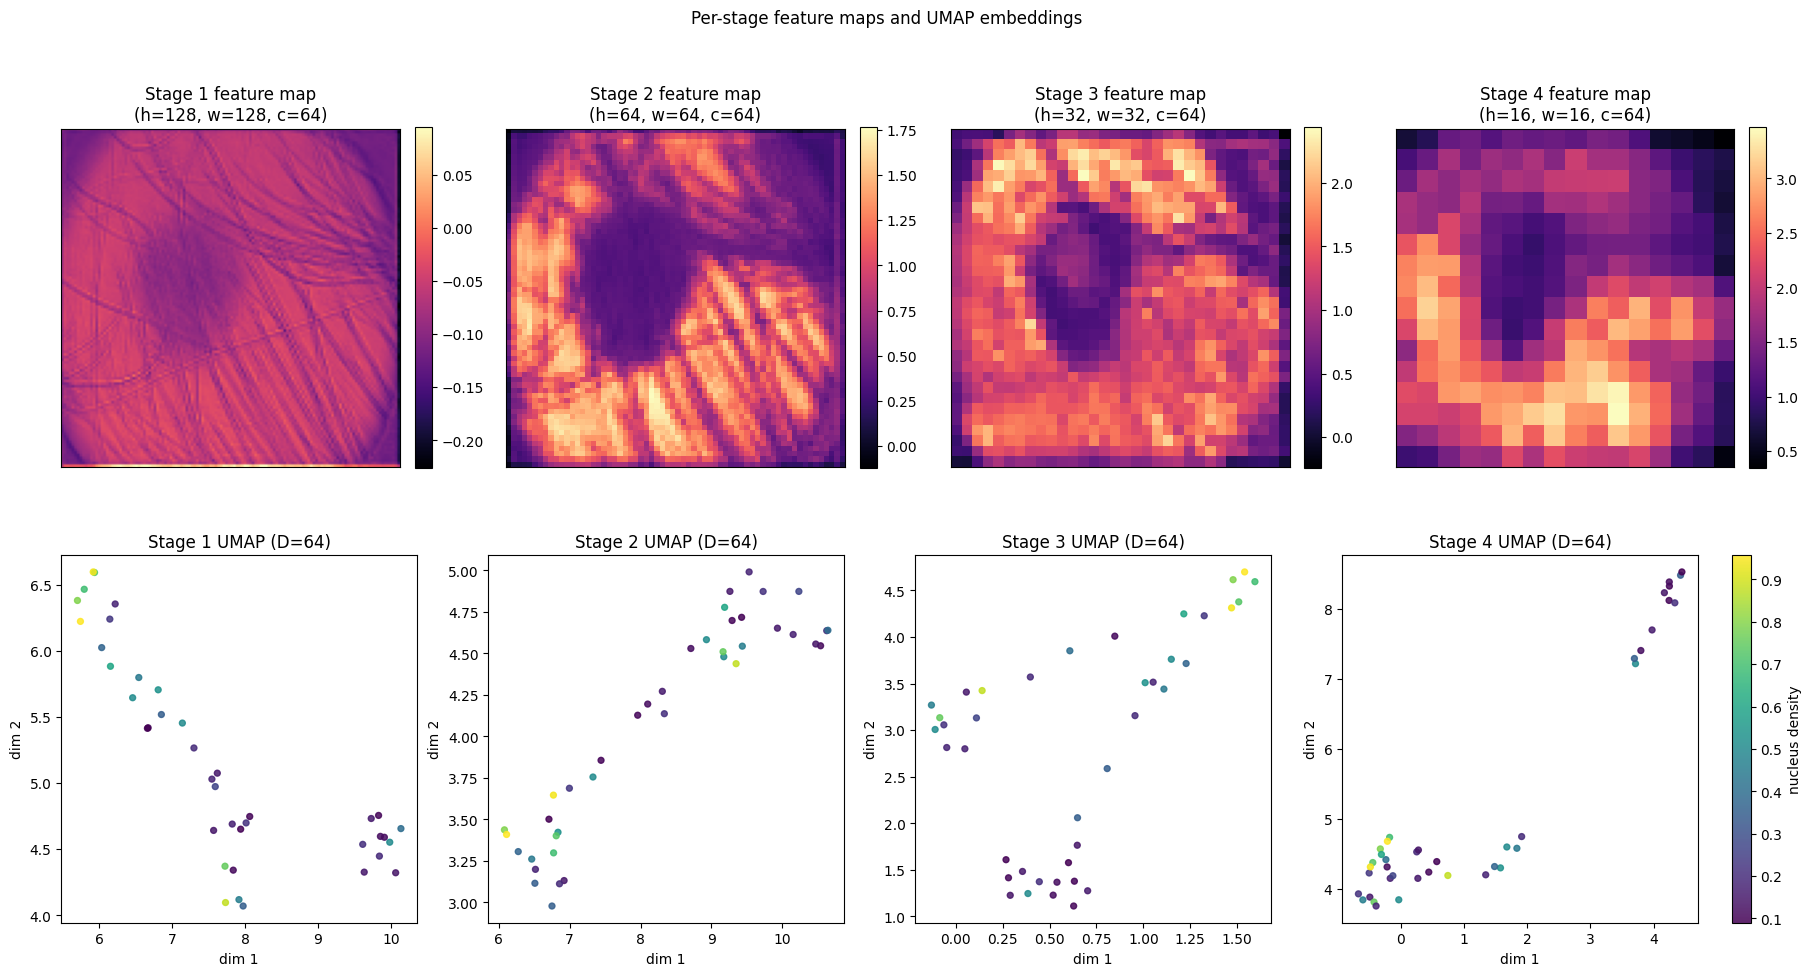

In [19]:
"""
For every DualBranchCanvasDownsample2D_SpatialGate stage in build_canvas_unet,
plot:
  (row 1) the stage's feature map for one example image (channel-averaged heatmap)
  (row 2) a 2D UMAP embedding of that stage's pooled features across the dataset

Usage:
    python plot_stage_feature_maps_and_umap.py

Assumes:
    - `build_canvas_unet` and all custom layers (DualBranchCanvasDownsample2D_SpatialGate,
      DualBranchCanvasUpsample2D_SpatialGate, conv_block, split_branch_block, etc.)
      are importable from your model module.
    - You have a batch of images (X) to run through the encoder, and optionally
      labels (y) for coloring the UMAP scatter plots (here: per-image nucleus density).
"""

import os
import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt

try:
    import umap
except ImportError as e:
    raise ImportError(
        "umap-learn not installed. Run: pip install umap-learn --break-system-packages"
    ) from e

# -----------------------------------------------------------------------
# 1. Import your model builder (edit this import to match your project)
# -----------------------------------------------------------------------

def get_stage_extractor(model):
    """
    Build a sub-model that outputs the 's' (spatial / `final(fused)`) tensor from
    every DualBranchCanvasDownsample2D_SpatialGate call in the model, in encoder
    order (stage 1 -> stage 4). Each downsample layer returns
    (final(fused), center_map, boundary_map) when use_structure_heads=True; we
    take the first element, since that's what actually feeds the next conv_block
    (i.e. p1..p4 in build_canvas_unet).
    """
    stage_outputs = []
    stage_names = []
    for layer in model.layers:
        if layer.__class__.__name__ == "DualBranchCanvasDownsample2D_SpatialGate":
            out = layer.output
            s = out[0] if isinstance(out, (list, tuple)) else out
            stage_outputs.append(s)
            stage_names.append(layer.name)

    if not stage_outputs:
        raise ValueError(
            "No DualBranchCanvasDownsample2D_SpatialGate layers found on model. "
            "Check the class name matches your layer definition exactly."
        )

    print(f"Found {len(stage_outputs)} downsample stages:")
    for i, (name, t) in enumerate(zip(stage_names, stage_outputs), start=1):
        print(f"  stage {i}: layer='{name}', shape={t.shape}")

    return tf.keras.Model(inputs=model.input, outputs=stage_outputs, name="stage_extractor")


def pool_bottleneck(feat_maps, mode="avg"):
    """
    feat_maps: (N, h, w, c) -> (N, c) per-sample vector.
    mode: 'avg' (global average pool) or 'avgmax' (concat avg+max pool, more discriminative).

    Note: 'avgmax' returns a (N, 2c) vector -- the pooled dimensionality D is
    double the layer's true channel count c, since it concatenates avg-pooled
    and max-pooled channels. Use the returned mode/c bookkeeping in the caller
    if you need to report the true channel count alongside D.
    """
    if mode == "avg":
        return feat_maps.mean(axis=(1, 2))
    elif mode == "avgmax":
        avg = feat_maps.mean(axis=(1, 2))
        mx = feat_maps.max(axis=(1, 2))
        return np.concatenate([avg, mx], axis=-1)
    else:
        raise ValueError("mode must be 'avg' or 'avgmax'")


def plot_stage_feature_maps_and_umap(
    stage_feats_list,
    stage_vecs_list,
    example_idx=0,
    labels=None,
    n_neighbors=8,
    pool_mode="avgmax",
    title="Per-stage feature maps and UMAP embeddings",
):
    """
    stage_feats_list: list of (N, h, w, c) raw feature-map arrays, one per stage.
    stage_vecs_list:  list of (N, D_i) pooled feature arrays, one per stage
                       (same order as stage_feats_list).
    example_idx: which sample in the batch to visualize the feature map for.
    pool_mode: which pooling mode produced stage_vecs_list ('avg' or 'avgmax'),
               used only to label the UMAP subplot titles correctly.
    """
    n_stages = len(stage_feats_list)
    fig, axes = plt.subplots(2, n_stages, figsize=(5.5 * n_stages, 10.5), squeeze=False)

    last_sc = None
    for i in range(n_stages):
        feats = stage_feats_list[i]
        vecs = stage_vecs_list[i]
        c = feats.shape[3]      # true channel count for this stage
        D = vecs.shape[1]       # pooled vector dimensionality fed into UMAP

        # ---- Row 1: channel-averaged feature map for one example image ----
        fmap = feats[example_idx].mean(axis=-1)  # (h, w)
        ax_fm = axes[0, i]
        im = ax_fm.imshow(fmap, cmap="magma")
        ax_fm.set_title(f"Stage {i + 1} feature map\n(h={feats.shape[1]}, w={feats.shape[2]}, c={c})")
        ax_fm.set_xticks([])
        ax_fm.set_yticks([])
        fig.colorbar(im, ax=ax_fm, fraction=0.046, pad=0.04)

        # ---- Row 2: 2D UMAP of pooled features across the dataset ----
        nn = min(n_neighbors, vecs.shape[0] - 1)
        reducer = umap.UMAP(n_neighbors=nn, min_dist=0.1, n_components=8, random_state=42)
        emb = reducer.fit_transform(vecs)

        ax_um = axes[1, i]
        if labels is not None:
            sc = ax_um.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="viridis", s=18, alpha=0.85)
            last_sc = sc
        else:
            ax_um.scatter(emb[:, 0], emb[:, 1], s=18, alpha=0.85)

        # With pool_mode="avg", D always equals the true channel count c.
        # (Kept the D != c fallback in case pool_mode is ever switched back
        # to "avgmax", where D = 2c.)
        if pool_mode == "avgmax" and D != c:
            ax_um.set_title(f"Stage {i + 1} UMAP (D={D} = avg+max of c={c} channels)")
        else:
            ax_um.set_title(f"Stage {i + 1} UMAP (D={D})")
        ax_um.set_xlabel("dim 1")
        ax_um.set_ylabel("dim 2")

    if labels is not None and last_sc is not None:
        fig.colorbar(last_sc, ax=axes[1, :].tolist(), fraction=0.02, pad=0.02, label="nucleus density")

    fig.suptitle(title)
    return fig


def main():
    # -------------------------------------------------------------------
    # 2. Build model + stage extractor
    # -------------------------------------------------------------------
    input_shape = (256, 256, 3)
    model, _, _ = build_canvas_unet(input_shape=input_shape, base_filters=64, num_classes=1)
    stage_extractor = get_stage_extractor(model)

    # -------------------------------------------------------------------
    # 3. Load CPM17 test set via tf.data
    # -------------------------------------------------------------------
    from glob import glob
    from PIL import Image

    IMG_DIR = "../dataset_split/test/images"
    MSK_DIR = "../dataset_split/test/masks"
    ds_batch_size = 38
    img_size = input_shape[0]

    def valid_name(p):
        return "Zone" not in os.path.basename(p)

    def stem(p):
        return os.path.splitext(os.path.basename(p))[0]

    MASK_SUFFIX = "_lesion"

    def mask_stem(p):
        name = os.path.splitext(os.path.basename(p))[0]
        if name.endswith(MASK_SUFFIX):
            name = name[: -len(MASK_SUFFIX)]
        return name

    image_paths = sorted(p for p in glob(os.path.join(IMG_DIR, "*")) if valid_name(p))
    mask_paths  = sorted(p for p in glob(os.path.join(MSK_DIR, "*")) if valid_name(p))

    mask_lookup = {mask_stem(p): p for p in mask_paths}
    paired_images, paired_masks, missing = [], [], []
    for img_p in image_paths:
        key = stem(img_p)          # images: no suffix
        if key in mask_lookup:
            paired_images.append(img_p)
            paired_masks.append(mask_lookup[key])
        else:
            missing.append(img_p)

    if missing:
        raise AssertionError(f"{len(missing)} image(s) have no matching mask, e.g.: {missing[:5]}")

    image_paths, mask_paths = paired_images, paired_masks
    print("Images found:", len(image_paths))

    def _load_numpy(img_path, mask_path):
        img_path = img_path.numpy().decode("utf-8")
        mask_path = mask_path.numpy().decode("utf-8")
        img = Image.open(img_path).convert("RGB").resize((img_size, img_size), Image.BILINEAR)
        mask = Image.open(mask_path).convert("L").resize((img_size, img_size), Image.NEAREST)
        img = np.array(img, dtype=np.float32) / 255.0
        mask = (np.array(mask) > 127.5).astype(np.float32)[..., None]
        return img, mask

    def load_image_mask(img_path, mask_path):
        img, mask = tf.py_function(_load_numpy, [img_path, mask_path], [tf.float32, tf.float32])
        img.set_shape([img_size, img_size, 3])
        mask.set_shape([img_size, img_size, 1])
        return img, mask

    test_dataset = (
        tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
        .map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(ds_batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Materialize images (for extractor.predict) and per-image mask density (for coloring)
    X_list, density_list = [], []
    for imgs, masks in test_dataset:
        X_list.append(imgs.numpy())
        density_list.append(masks.numpy().mean(axis=(1, 2, 3)))  # fraction of positive pixels
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(density_list, axis=0)  # continuous "label" = nucleus density per image
    print("Loaded images:", X.shape, "| density range:", y.min(), "-", y.max())

    # -------------------------------------------------------------------
    # 4. Extract per-stage feature maps + pool
    # -------------------------------------------------------------------
    stage_feats = stage_extractor.predict(X, batch_size=ds_batch_size, verbose=1)
    # Multi-output model -> list of (N, h, w, c) arrays, one per stage
    if not isinstance(stage_feats, (list, tuple)):
        stage_feats = [stage_feats]

    POOL_MODE = "avg"  # viz-only: keeps D == true channel count c. Keep in sync
                        # with plot_stage_feature_maps_and_umap(pool_mode=...)
    stage_vecs = [pool_bottleneck(f, mode=POOL_MODE) for f in stage_feats]
    for i, (f, v) in enumerate(zip(stage_feats, stage_vecs), start=1):
        print(f"Stage {i}: feature map shape={f.shape} (c={f.shape[3]}), pooled vector shape={v.shape} (D={v.shape[1]})")

    # -------------------------------------------------------------------
    # 5. Plot feature maps (top row) + UMAP embeddings (bottom row)
    # -------------------------------------------------------------------
    fig = plot_stage_feature_maps_and_umap(
        stage_feats,
        stage_vecs,
        example_idx=0,
        labels=y,
        pool_mode=POOL_MODE,
        title="Per-stage feature maps and UMAP embeddings",
    )
    fig.savefig("stage_feature_maps_and_umap.png", dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main()

In [20]:
from glob import glob
import os
import tensorflow as tf
import numpy as np
from PIL import Image

# =========================================================
# CONFIG  -- edit these to match your machine
# =========================================================
IMG_DIR = "../dataset_split/test/images"
MSK_DIR = "../dataset_split/test/masks"
img_size   = 256
batch_size = 38
AUTOTUNE = tf.data.AUTOTUNE
MASK_SUFFIX = "_lesion"


def _valid_name(p):
    return "Zone" not in os.path.basename(p)


def _image_stem(p):
    return os.path.splitext(os.path.basename(p))[0]


def _mask_stem(p):
    name = os.path.splitext(os.path.basename(p))[0]
    if name.endswith(MASK_SUFFIX):
        name = name[: -len(MASK_SUFFIX)]
    return name


def _load_numpy(img_path, mask_path):
    img_path = img_path.numpy().decode("utf-8")
    mask_path = mask_path.numpy().decode("utf-8")

    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_size, img_size), Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255.0

    mask = Image.open(mask_path).convert("L")
    mask = mask.resize((img_size, img_size), Image.NEAREST)
    mask = np.array(mask, dtype=np.float32)
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask


def _load_image_mask(img_path, mask_path):
    img, mask = tf.py_function(_load_numpy, [img_path, mask_path], [tf.float32, tf.float32])
    img.set_shape([img_size, img_size, 3])
    mask.set_shape([img_size, img_size, 1])
    return img, {"segmentation": mask}


def build_test_dataset(img_dir=IMG_DIR, msk_dir=MSK_DIR):
    image_paths = sorted([p for p in glob(os.path.join(img_dir, "*")) if _valid_name(p)])
    mask_paths = sorted([p for p in glob(os.path.join(msk_dir, "*")) if _valid_name(p)])

    mask_lookup = {_mask_stem(p): p for p in mask_paths}
    paired_images, paired_masks, missing = [], [], []

    for img_p in image_paths:
        key = _image_stem(img_p)
        if key in mask_lookup:
            paired_images.append(img_p)
            paired_masks.append(mask_lookup[key])
        else:
            missing.append(img_p)

    if missing:
        raise AssertionError(f"{len(missing)} image(s) have no matching mask, e.g.: {missing[:5]}")

    print("Paired samples:", len(paired_images))

    ds = (
        tf.data.Dataset
        .from_tensor_slices((paired_images, paired_masks))
        .map(_load_image_mask, num_parallel_calls=AUTOTUNE)
        .batch(batch_size)
        .prefetch(AUTOTUNE)
    )
    return ds


def get_sample_batch(n_images=8, img_dir=IMG_DIR, msk_dir=MSK_DIR):
    """Convenience: pull `n_images` real images from the test set as a numpy array (N,H,W,3) in [0,1]."""
    ds = build_test_dataset(img_dir, msk_dir)
    images_batch, _ = next(iter(ds.take(1)))
    images_batch = images_batch.numpy()
    return images_batch[:n_images]


if __name__ == "__main__":
    batch = get_sample_batch(4)
    print("Sample batch shape:", batch.shape)

Paired samples: 40
Sample batch shape: (4, 256, 256, 3)


In [21]:
import numpy as np
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim

def _minmax(x, eps=1e-8):
    lo, hi = np.min(x), np.max(x)
    return (x - lo) / (hi - lo + eps)

def shannon_entropy(x, bins=64):
    hist, _ = np.histogram(x.flatten(), bins=bins, density=False)
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def effective_rank(x):
    # x: (H, W, C) -> flatten spatial, treat channels as variables
    H, W, C = x.shape
    flat = x.reshape(H * W, C).astype(np.float64)
    flat = flat - flat.mean(axis=0, keepdims=True)
    if flat.shape[0] < 2 or C < 2:
        return 1.0
    cov = np.cov(flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, 0, None)
    s = eigvals.sum()
    if s <= 1e-12:
        return 1.0
    p = eigvals / s
    p = p[p > 1e-12]
    H_shannon = -np.sum(p * np.log(p))
    return float(np.exp(H_shannon))  # Roy & Vetterli effective rank

def energy_ratio(x_in, x_out):
    return float(np.mean(x_out ** 2) / (np.mean(x_in ** 2) + 1e-12))

def variance_ratio(x_in, x_out):
    return float(np.var(x_out) / (np.var(x_in) + 1e-12))

def reconstruction_error(x_in, x_out):
    """Upsample x_out back to x_in's spatial size and compare."""
    x_out_t = tf.convert_to_tensor(x_out[None, ...], dtype=tf.float32)
    target_hw = x_in.shape[:2]
    up = tf.image.resize(x_out_t, target_hw, method="bilinear")[0].numpy()

    a = _minmax(x_in)
    b = _minmax(up)

    mse = float(np.mean((a - b) ** 2))
    # channel-averaged SSIM (skimage needs 2D or multichannel-aware call)
    try:
        s = ssim(a, b, channel_axis=-1, data_range=1.0)
    except TypeError:
        s = ssim(a, b, multichannel=True, data_range=1.0)
    return mse, float(s)

def stage_metrics(x_in, x_out):
    """x_in, x_out: numpy arrays (H, W, C) for a single sample."""
    mse, ssim_val = reconstruction_error(x_in, x_out)
    return {
        "entropy_in": shannon_entropy(x_in),
        "entropy_out": shannon_entropy(x_out),
        "eff_rank_in": effective_rank(x_in),
        "eff_rank_out": effective_rank(x_out),
        "energy_ratio": energy_ratio(x_in, x_out),
        "variance_ratio": variance_ratio(x_in, x_out),
        "recon_mse": mse,
        "recon_ssim": ssim_val,
    }

In [22]:
from tensorflow.keras import layers
@tf.keras.utils.register_keras_serializable(package="Custom")
class GeodesicDownsample2D(layers.Layer):
    """
    Riemannian geodesic pooling via iterative intrinsic mean computation
    with a learnable diagonal metric and configurable robust weighting
    kernels (Huber, Tukey, Cauchy, Geman-McClure).
    """

    def __init__(
        self,
        pool_size=2,
        geo_iters=3,
        geo_temp=1.0,
        robust_kernel="huber",
        tukey_c=4.685,
        huber_delta=1.0,
        cauchy_alpha=1.0,
        geman_lambda=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.pool_size = pool_size
        self.geo_iters = geo_iters
        self.geo_temp = geo_temp
        self.robust_kernel = robust_kernel.lower()

        # kernel params
        self.huber_delta = huber_delta
        self.tukey_c = tukey_c
        self.cauchy_alpha = cauchy_alpha
        self.geman_lambda = geman_lambda

    def build(self, input_shape):
        c = input_shape[-1]
        self.metric_raw = self.add_weight(
            shape=(c,),
            initializer=tf.keras.initializers.Constant(1.0),
            trainable=True,
            name="metric_diag_unconstrained"
        )
        super().build(input_shape)

    # ---------------- robust weighting functions ----------------
    def _robust_weights(self, dist_sq):
        eps = 1e-9

        if self.robust_kernel == "huber":
            delta = self.huber_delta
            mask = dist_sq <= delta**2
            w_quad = 1.0
            w_lin = delta / (tf.sqrt(dist_sq) + eps)
            return tf.where(mask, w_quad, w_lin)

        if self.robust_kernel == "tukey":
            c = self.tukey_c
            mask = dist_sq <= c**2
            z = dist_sq / (c**2 + eps)
            w = (1 - z)**2
            return tf.where(mask, w, tf.zeros_like(dist_sq))

        if self.robust_kernel == "cauchy":
            a = self.cauchy_alpha
            return 1.0 / (1.0 + dist_sq / (a**2) + eps)

        if self.robust_kernel == "geman":
            lam = self.geman_lambda
            return 1.0 / ((1.0 + dist_sq / (lam + eps))**2)

        return tf.nn.softmax(-dist_sq, axis=-1)

    # ---------------- main pooling routine ----------------
    def call(self, x):
        if isinstance(self.pool_size, int):
            ph = pw = self.pool_size
        else:
            ph, pw = self.pool_size

        b, h, w, c = tf.unstack(tf.shape(x))
        pad_h = tf.math.floormod(-h, ph)
        pad_w = tf.math.floormod(-w, pw)
        x_pad = tf.pad(x, [[0,0],[0,pad_h],[0,pad_w],[0,0]])

        Hp = tf.shape(x_pad)[1] // ph
        Wp = tf.shape(x_pad)[2] // pw

        ksizes = [1, ph, pw, 1]
        strides = [1, ph, pw, 1]
        patches = tf.image.extract_patches(
            images=x_pad,
            sizes=ksizes,
            strides=strides,
            rates=[1,1,1,1],
            padding="VALID"
        )

        P = ph * pw
        patches = tf.reshape(patches, [b, Hp, Wp, P, c])

        metric = tf.nn.softplus(self.metric_raw) + 1e-6
        mean = tf.reduce_mean(patches, axis=3)

        for _ in range(self.geo_iters):
            diff = patches - tf.expand_dims(mean, axis=3)
            dist_sq = tf.reduce_sum(diff * diff * tf.reshape(metric, [1,1,1,1,c]), axis=-1)
            w = self._robust_weights(dist_sq)
            w = tf.nn.softmax(w / self.geo_temp, axis=-1)
            w = tf.expand_dims(w, axis=-1)
            mean = tf.reduce_sum(patches * w, axis=3)

        return mean

    def get_config(self):
        base = super().get_config()
        base.update({
            "pool_size": self.pool_size,
            "geo_iters": self.geo_iters,
            "geo_temp": self.geo_temp,
            "robust_kernel": self.robust_kernel,
            "tukey_c": self.tukey_c,
            "huber_delta": self.huber_delta,
            "cauchy_alpha": self.cauchy_alpha,
            "geman_lambda": self.geman_lambda
        })
        return base


In [23]:
import numpy as np
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim

def _minmax(x, eps=1e-8):
    lo, hi = np.min(x), np.max(x)
    return (x - lo) / (hi - lo + eps)

def shannon_entropy(x, bins=64):
    hist, _ = np.histogram(x.flatten(), bins=bins, density=False)
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def effective_rank(x):
    # x: (H, W, C) -> flatten spatial, treat channels as variables
    H, W, C = x.shape
    flat = x.reshape(H * W, C).astype(np.float64)
    flat = flat - flat.mean(axis=0, keepdims=True)
    if flat.shape[0] < 2 or C < 2:
        return 1.0
    cov = np.cov(flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, 0, None)
    s = eigvals.sum()
    if s <= 1e-12:
        return 1.0
    p = eigvals / s
    p = p[p > 1e-12]
    H_shannon = -np.sum(p * np.log(p))
    return float(np.exp(H_shannon))  # Roy & Vetterli effective rank

def energy_ratio(x_in, x_out):
    return float(np.mean(x_out ** 2) / (np.mean(x_in ** 2) + 1e-12))

def variance_ratio(x_in, x_out):
    return float(np.var(x_out) / (np.var(x_in) + 1e-12))

def upsample_to(x_out, target_hw):
    """Bilinear-upsample x_out (H,W,C) back to target_hw. This IS the 'reconstructed' image."""
    x_out_t = tf.convert_to_tensor(x_out[None, ...], dtype=tf.float32)
    up = tf.image.resize(x_out_t, target_hw, method="bilinear")[0].numpy()
    return up

def reconstruction_error(x_in, x_out, recon=None):
    """Upsample x_out back to x_in's spatial size and compare. Pass a precomputed
    `recon` (from upsample_to) to avoid resizing twice when you also want to plot it."""
    if recon is None:
        recon = upsample_to(x_out, x_in.shape[:2])

    a = _minmax(x_in)
    b = _minmax(recon)

    mse = float(np.mean((a - b) ** 2))
    # channel-averaged SSIM (skimage needs 2D or multichannel-aware call)
    try:
        s = ssim(a, b, channel_axis=-1, data_range=1.0)
    except TypeError:
        s = ssim(a, b, multichannel=True, data_range=1.0)
    return mse, float(s)

def stage_metrics(x_in, x_out):
    """x_in, x_out: numpy arrays (H, W, C) for a single sample."""
    mse, ssim_val = reconstruction_error(x_in, x_out)
    return {
        "entropy_in": shannon_entropy(x_in),
        "entropy_out": shannon_entropy(x_out),
        "eff_rank_in": effective_rank(x_in),
        "eff_rank_out": effective_rank(x_out),
        "energy_ratio": energy_ratio(x_in, x_out),
        "variance_ratio": variance_ratio(x_in, x_out),
        "recon_mse": mse,
        "recon_ssim": ssim_val,
    }

In [24]:
"""
Compare MaxPooling vs GeodesicDownsample2D across consecutive pooling
stages, on real images pulled from your test set.

Outputs (saved next to this script):
  - feature_maps.png     : visual grid, one column per stage, input vs both pools
  - metric_curves.png    : per-stage information-loss metrics, mean over the batch
  - metrics_table.csv    : the raw numbers behind the plot

Run:
    python compare_pooling.py
"""

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import csv


# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
N_STAGES = 4          # how many consecutive poolings to apply
N_IMAGES = 8           # how many real test-set images to average metrics over
VIS_IMAGE_IDX = 0      # which of those images to draw in the feature-map grid


def run_stages(x, n_stages, make_layer):
    """x: (1,H,W,C) tensor. Returns list of tensors, index 0 = input, index i = after stage i."""
    outs = [x]
    cur = x
    for _ in range(n_stages):
        cur = make_layer()(cur)
        outs.append(cur)
    return outs


def compare_on_image(x_single):
    """x_single: (1,H,W,3) tensor for ONE image. Returns stage outputs + per-stage metrics."""
    max_stages = run_stages(x_single, N_STAGES, lambda: tf.keras.layers.MaxPool2D(2))
    geo_stages = run_stages(x_single, N_STAGES, lambda: GeodesicDownsample2D(pool_size=2))

    max_metrics, geo_metrics = [], []
    for i in range(1, N_STAGES + 1):
        max_metrics.append(stage_metrics(max_stages[i - 1][0].numpy(), max_stages[i][0].numpy()))
        geo_metrics.append(stage_metrics(geo_stages[i - 1][0].numpy(), geo_stages[i][0].numpy()))

    return max_stages, geo_stages, max_metrics, geo_metrics


def plot_feature_maps(max_stages, geo_stages, out_path="feature_maps.png"):
    n_stages = len(max_stages) - 1
    fig, axes = plt.subplots(2, n_stages + 1, figsize=(3.2 * (n_stages + 1), 6.4))
    for col in range(n_stages + 1):
        m_img = max_stages[col][0].numpy()
        g_img = geo_stages[col][0].numpy()
        m_disp = (m_img - m_img.min()) / (m_img.max() - m_img.min() + 1e-8)
        g_disp = (g_img - g_img.min()) / (g_img.max() - g_img.min() + 1e-8)
        axes[0, col].imshow(m_disp[..., :3])
        axes[0, col].set_title("Input" if col == 0 else f"MaxPool  stage {col}")
        axes[0, col].axis("off")
        axes[1, col].imshow(g_disp[..., :3])
        axes[1, col].set_title("Input" if col == 0 else f"Geodesic  stage {col}")
        axes[1, col].axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=130)
    plt.close()
    print("saved", out_path)


def _disp(x):
    """min-max normalize a (H,W,C) array to [0,1] for imshow, keep only first 3 channels."""
    x = x[..., :3]
    return (x - x.min()) / (x.max() - x.min() + 1e-8)


def plot_stage_details(max_stages, geo_stages, max_metrics, geo_metrics, out_path="stage_details.png"):
    """
    One row per stage, per method: Input | Downsampled | Reconstructed (upsampled back),
    with MSE/SSIM annotated under the reconstructed image.
    MaxPool rows and Geodesic rows are interleaved so each stage is easy to compare.
    """
    n_stages = len(max_stages) - 1
    fig, axes = plt.subplots(2 * n_stages, 3, figsize=(9, 3.1 * 2 * n_stages))
    if n_stages == 1:
        axes = axes.reshape(2, 3)

    for s in range(1, n_stages + 1):
        for row_offset, (label, stages, mlist) in enumerate([
            ("MaxPool", max_stages, max_metrics),
            ("Geodesic", geo_stages, geo_metrics),
        ]):
            row = 2 * (s - 1) + row_offset
            x_in = stages[s - 1][0].numpy()
            x_out = stages[s][0].numpy()
            recon = upsample_to(x_out, x_in.shape[:2])
            m = mlist[s - 1]

            axes[row, 0].imshow(_disp(x_in))
            axes[row, 0].set_title(f"{label} stage {s} — input\n{x_in.shape[0]}x{x_in.shape[1]}")
            axes[row, 0].axis("off")

            axes[row, 1].imshow(_disp(x_out))
            axes[row, 1].set_title(f"downsampled\n{x_out.shape[0]}x{x_out.shape[1]}")
            axes[row, 1].axis("off")

            axes[row, 2].imshow(_disp(recon))
            axes[row, 2].set_title(
                f"reconstructed (upsampled back)\nMSE={m['recon_mse']:.4f}  SSIM={m['recon_ssim']:.3f}  "
                f"H={m['entropy_out']:.2f}b"
            )
            axes[row, 2].axis("off")

    plt.tight_layout()
    plt.savefig(out_path, dpi=130)
    plt.close()
    print("saved", out_path)


def aggregate(metrics_per_image, key):
    """metrics_per_image: list (over images) of list (over stages) of dicts."""
    n_stages = len(metrics_per_image[0])
    means, stds = [], []
    for s in range(n_stages):
        vals = [img_metrics[s][key] for img_metrics in metrics_per_image]
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    return np.array(means), np.array(stds)


def plot_metric_curves(all_max_metrics, all_geo_metrics, out_path="metric_curves.png"):
    keys = ["recon_mse", "recon_ssim", "eff_rank_out", "entropy_out", "energy_ratio", "variance_ratio"]
    titles = ["Reconstruction MSE\n(lower = less info lost)",
              "Reconstruction SSIM\n(higher = less info lost)",
              "Effective rank\n(channel diversity retained)",
              "Entropy (bits)\n(value diversity retained)",
              "Energy ratio (out / in)",
              "Variance ratio (out / in)"]
    n_stages = len(all_max_metrics[0])
    stages = list(range(1, n_stages + 1))

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, k, t in zip(axes.flat, keys, titles):
        m_mean, m_std = aggregate(all_max_metrics, k)
        g_mean, g_std = aggregate(all_geo_metrics, k)
        ax.errorbar(stages, m_mean, yerr=m_std, marker="o", capsize=3, label="MaxPool")
        ax.errorbar(stages, g_mean, yerr=g_std, marker="s", capsize=3, label="Geodesic")
        ax.set_title(t)
        ax.set_xlabel("Pooling stage")
        ax.set_xticks(stages)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=130)
    plt.close()
    print("saved", out_path)


def save_csv(all_max_metrics, all_geo_metrics, out_path="metrics_table.csv"):
    keys = list(all_max_metrics[0][0].keys())
    n_stages = len(all_max_metrics[0])
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["stage", "pool_type"] + keys)
        for s in range(n_stages):
            m_row = ["mean_" + k for k in keys]
            m_vals = [np.mean([img[s][k] for img in all_max_metrics]) for k in keys]
            g_vals = [np.mean([img[s][k] for img in all_geo_metrics]) for k in keys]
            writer.writerow([s + 1, "maxpool"] + [round(v, 5) for v in m_vals])
            writer.writerow([s + 1, "geodesic"] + [round(v, 5) for v in g_vals])
    print("saved", out_path)


if __name__ == "__main__":
    print(f"Loading {N_IMAGES} images from {IMG_DIR} ...")
    batch = get_sample_batch(N_IMAGES)  # (N, H, W, 3) numpy, values in [0,1]
    print("Batch shape:", batch.shape)

    all_max_metrics, all_geo_metrics = [], []
    vis_max_stages, vis_geo_stages = None, None

    for i in range(batch.shape[0]):
        x = tf.convert_to_tensor(batch[i:i + 1], dtype=tf.float32)
        max_stages, geo_stages, max_metrics, geo_metrics = compare_on_image(x)
        all_max_metrics.append(max_metrics)
        all_geo_metrics.append(geo_metrics)
        if i == VIS_IMAGE_IDX:
            vis_max_stages, vis_geo_stages = max_stages, geo_stages

    plot_feature_maps(vis_max_stages, vis_geo_stages)
    plot_stage_details(vis_max_stages, vis_geo_stages, all_max_metrics[VIS_IMAGE_IDX], all_geo_metrics[VIS_IMAGE_IDX])
    plot_metric_curves(all_max_metrics, all_geo_metrics)
    save_csv(all_max_metrics, all_geo_metrics)

    print(f"\nAveraged over {batch.shape[0]} images, per-stage summary:")
    for s in range(N_STAGES):
        print(f"\n-- Stage {s + 1} --")
        for k in all_max_metrics[0][0].keys():
            m_mean, _ = aggregate(all_max_metrics, k)
            g_mean, _ = aggregate(all_geo_metrics, k)
            print(f"  {k:15s}  MaxPool={m_mean[s]:.4f}   Geodesic={g_mean[s]:.4f}")

Loading 8 images from ../dataset_split/test/images ...
Paired samples: 40
Batch shape: (8, 256, 256, 3)
saved feature_maps.png
saved stage_details.png
saved metric_curves.png
saved metrics_table.csv

Averaged over 8 images, per-stage summary:

-- Stage 1 --
  entropy_in       MaxPool=5.5674   Geodesic=5.5674
  entropy_out      MaxPool=5.5814   Geodesic=5.6284
  eff_rank_in      MaxPool=1.1814   Geodesic=1.1814
  eff_rank_out     MaxPool=1.1839   Geodesic=1.1797
  energy_ratio     MaxPool=1.0472   Geodesic=0.9987
  variance_ratio   MaxPool=0.9744   Geodesic=0.9857
  recon_mse        MaxPool=0.0013   Geodesic=0.0010
  recon_ssim       MaxPool=0.8824   Geodesic=0.9111

-- Stage 2 --
  entropy_in       MaxPool=5.5814   Geodesic=5.6284
  entropy_out      MaxPool=5.5540   Geodesic=5.6578
  eff_rank_in      MaxPool=1.1839   Geodesic=1.1797
  eff_rank_out     MaxPool=1.1877   Geodesic=1.1770
  energy_ratio     MaxPool=1.0561   Geodesic=0.9985
  variance_ratio   MaxPool=0.9523   Geodesic=0.9824